# Online Error Control for ML Intrusion Detection

Reproduction notebook for the IEEE SaTML 2027 submission. Every number and figure in the
paper is produced below, next to the text that explains it.

**How to run.** Set `MODE` in the next cell.

| MODE | what it does | needs | time |
|---|---|---|---|
| `"paper"` | loads the shipped results in `lib/out/` | nothing | ~1 min |
| `"full"` | recomputes everything from LSPR23 | the dataset, ~27 GB disk | ~2-3 h |

`"paper"` is the default and is enough to check every figure and table against the text.
`"full"` re-derives them from the raw flows; both produce identical output, which is the
point of shipping the artifacts alongside the code.

The theory sections need no data in either mode: the closed forms are verified numerically
in about a minute, without LSPR23.

**Where things live.** `lib/` holds the experiment scripts, one per result, each exposing
`main()`. `lib/out/` holds their JSON output. `lib/data/` holds the red-team narratives.
The flow data itself is not shipped; see `data/README.md`.

In [1]:
MODE = "paper"          # "paper" = load shipped results | "full" = recompute from LSPR23

import json, sys, time, io, contextlib
from pathlib import Path
import numpy as np

LIB = Path("lib").resolve()
OUT = LIB / "out"
sys.path.insert(0, str(LIB))
import os
os.chdir(LIB)

def result(module, key=None, **kw):
    '''Return one stage's results: recompute in "full" mode, load the shipped JSON otherwise.'''
    f = OUT / (key or module.split("_")[0] + ".json")
    if MODE == "full":
        import importlib
        m = importlib.import_module(module)
        t = time.time()
        with contextlib.redirect_stdout(io.StringIO()):
            try: m.main(**kw)
            except SystemExit: pass
        print(f"  {module}: recomputed in {time.time()-t:.0f}s")
    return json.load(open(f))

def show(rows, cols=None, n=None):
    '''Compact table print, so the notebook reads without a dataframe dependency.'''
    rows = rows[:n] if n else rows
    cols = cols or list(rows[0])
    w = {c: max(len(str(c)), *(len(f"{r.get(c)}") for r in rows)) for c in cols}
    print("  " + "  ".join(f"{c:>{w[c]}}" for c in cols))
    for r in rows:
        print("  " + "  ".join(f"{r.get(c)!s:>{w[c]}}" for c in cols))

def rng(v, f="{:.3f}"):
    '''Render a [min, median, max] triple as one string.'''
    return "--" if v is None else " / ".join("--" if x is None else f.format(x) for x in v)

print(f"MODE = {MODE!r}   artifacts: {len(list(OUT.glob('*.json')))} files")

MODE = 'paper'   artifacts: 57 files


---
## 1. The theory, verified without data

Every closed form the paper states is checked numerically here. None of this needs LSPR23,
so a reader can confirm the theoretical contribution before deciding whether to download
anything. Each script prints its own pass/fail count and exits non-zero on any failure.

In [2]:
THEORY = [
    ("t15_T3_theorem",       "feasibility theorem and e-LOND check"),
    ("t18_T4_padding",       "padding-robustness theorem"),
    ("t21f_H6_scaling",      "what the online e-BH escape costs"),
    ("t34a_E1_derivation",   "smoothed and continuous evidence"),
    ("t35a_E2_derivation",   "periodic restart"),
    ("t36a_E3_derivation",   "precommitted weights and front-load cost"),
    ("t32a_E11_derivation",  "padding / state coincidence"),
    ("t38a_E4_derivation",   "calibration contamination"),
    ("t39a_E6_derivation",   "cross-window selection"),
    ("t41a_E8_derivation",   "operational units"),
    ("t42a_E9_derivation",   "timestamp ties"),
]

import importlib, re
for mod, desc in THEORY:
    buf = io.StringIO()
    t = time.time()
    try:
        with contextlib.redirect_stdout(buf):
            importlib.import_module(mod).main()
        ok = True
    except SystemExit as e:
        ok = not e.code
    out = buf.getvalue()
    m = (re.search(r"PASSED (\d+) / (\d+)", out) or re.search(r"(\d+) checks passed", out)
         or re.search(r"(\d+)\s*/\s*(\d+)\s+checks", out))
    tally = "/".join(g for g in (m.groups() if m else ()) if g) if m else "asserts"
    print(f"  {'PASS' if ok else 'FAIL'}  {mod:<24} {tally:>9} checks  {time.time()-t:5.1f}s  {desc}")

  PASS  t15_T3_theorem             asserts checks    3.1s  feasibility theorem and e-LOND check


  PASS  t18_T4_padding             asserts checks    1.4s  padding-robustness theorem


  PASS  t21f_H6_scaling            asserts checks    1.8s  what the online e-BH escape costs


  PASS  t34a_E1_derivation             152 checks    8.8s  smoothed and continuous evidence


  PASS  t35a_E2_derivation             201 checks   11.3s  periodic restart


  PASS  t36a_E3_derivation             115 checks    0.3s  precommitted weights and front-load cost


  PASS  t32a_E11_derivation          40/40 checks    0.7s  padding / state coincidence


  PASS  t38a_E4_derivation           32/32 checks    0.9s  calibration contamination


  PASS  t39a_E6_derivation           29/29 checks    0.6s  cross-window selection
  PASS  t41a_E8_derivation           25/25 checks    0.0s  operational units


  PASS  t42a_E9_derivation           17/17 checks    1.5s  timestamp ties


---
## 2. C1 — when can an online guarantee produce any alert?

Threshold conformal evidence at rank `k` is bounded above by the **evidence ceiling**
`M = (|C|+1)/k`. Online error-control procedures shrink the level `alpha_t` as the stream
advances. A rejection needs evidence at least `1/alpha_t`, so once `alpha_t` falls below
`1/M` no alert is possible however anomalous the traffic — and for the procedures whose
spending index advances on every hypothesis, that state is absorbing.

The horizon is exact: retaining feasibility over `T` hypotheses needs `|C| >= kT/w0 - 1`.

In [3]:
t15 = result("t15_T3_theorem", "t15_T3.json")
print("Absorbing Delta* -- the step past which no rejection is possible:\n")
show(t15["absorbing_delta"], ["gamma", "NC_1e4", "NC_1e6", "NC_1e8"])
print("\nThe sharp condition gamma_t * t^d -> 0:\n")
show(t15["sharp_condition"], ["gamma", "max_t_gamma", "limit_t_gamma", "d2_diverges"])

Absorbing Delta* -- the step past which no rejection is possible:

           gamma   NC_1e4   NC_1e6   NC_1e8
  gamma ~ j^-1.6    34567  6543160  9951885
      gamma ~ JM  9680767  9996754  9999969

The sharp condition gamma_t * t^d -> 0:

           gamma          max_t_gamma           limit_t_gamma  d2_diverges
  gamma ~ j^-1.6   0.4374901657744735  2.7603763323326093e-05         True
      gamma ~ JM  0.07639284081309781     0.04105050920288316         True


**Every procedure at every window (`t21c`).** The full matrix behind the appendix's detection and
procedure tables: five windows, two detector seeds, the covered procedures under horizon-free (`poly`) and
horizon-uniform spending, and the e-GAI-weighted family. These counts use the first-flow within-bucket
order, the optimistic upper bound the paper labels as such; the canonical-order headline is in section 3.1.

In [4]:
t21c = result("t21c_H6_positions", "t21c_H6_positions.json")
rows = sorted((r for r in t21c["rows"] if r["proc"] == "e-LOND" and r["gamma"] == "poly"),
              key=lambda r: (r["pos"], r["seed"]))
print("e-LOND, gamma ~ j^-1.6, two-hour host-pair grouping, first-flow order:\n")
show([{"position": r["pos"], "seed": r["seed"], "AUROC": round(r["auroc"], 3), "T": r["T"], "|C|": r["NC"],
       "margin": f"{r['margin']:+.3f}", "rejections": r["rejections"],
       "FDP": "--" if r["fdp"] is None else round(r["fdp"], 3), "recall": round(r["recall"], 3),
       "silent": f"{100*r['silent']:.1f}%"} for r in rows])
print("\nevery procedure, min / median / max over the ten window x seed cells:\n")
show([{"procedure": s["proc"], "spending": s["gamma"], "rejections": rng(s["rejections"], "{:g}"),
       "FDP": rng(s["fdp"]), "recall": rng(s["recall"]),
       "cells with a rejection": f"{s['n_with_rejections']}/{s['n_cfg']}"}
      for grp in ("poly", "uniform", "egai") for s in t21c["summary"][grp]])

e-LOND, gamma ~ j^-1.6, two-hour host-pair grouping, first-flow order:

  position  seed  AUROC      T      |C|  margin  rejections  FDP  recall  silent
      0.55     0  0.916  57368  2448993  +0.067          18  0.0   0.065   90.1%
      0.55     1  0.927  57368  2448993  +0.067          18  0.0   0.065   90.1%
      0.62     0  0.799  49267  2449031  +0.243          13  0.0   0.033   90.5%
      0.62     1  0.871  49267  2449031  +0.243          12  0.0    0.03   90.9%
       0.7     0  0.914  37231  2287988  +0.536          30  0.0   0.105   80.1%
       0.7     1  0.847  37231  2287988  +0.536           0   --     0.0   97.7%
      0.77     0  0.828  31672  2116418  +0.671          31  0.0   0.126   77.3%
      0.77     1  0.833  31672  2116418  +0.671          31  0.0   0.126   77.3%
      0.85     0  0.999  31568  1813113  +0.436          72  0.0   0.282   65.4%
      0.85     1    1.0  31568  1813113  +0.436          71  0.0   0.278   65.7%

every procedure, min / median / max 

**Horizon misspecification (`t21d`).** One cell, the stress window at seed 0, with horizon-uniform
spending sized for `T_hat = c*T`. Online e-BH keeps most of its rejections under a 100x over-estimate of the
horizon; LOND and LORD++ lose everything once the horizon is overstated enough. This illustrates the
mechanism; it is not a measured rate.

In [5]:
t21d = result("t21d_H6_horizon", "t21d_H6_horizon.json")
c = t21d["config"]
print(f"stress window {c['POS']}, seed 0: T = {c['T']:,}; rejections when the horizon is set to c*T\n")
procs = []
for r in t21d["rows"]:
    if r["proc"] not in procs:
        procs.append(r["proc"])
show([{"procedure": p, **{f"c={x:g}": next((r["rejections"] for r in t21d["rows"] if r["proc"] == p and r["c"] == x), "--")
                          for x in t21d["cs"]}} for p in procs if p != "ADDIS"])
addis = [r for r in t21d["rows"] if r["proc"] == "ADDIS"]
if addis:
    print(f"\n  ADDIS has no horizon to misspecify: {addis[0]['rejections']} rejections throughout")

stress window 0.85, seed 0: T = 31,568; rejections when the horizon is set to c*T

    procedure  c=0.1  c=0.25  c=0.5  c=1  c=2  c=5  c=10  c=100
  LOND/e-LOND     70      71    131  151  151    0     0      0
       LORD++     70     151    152  151    0    0     0      0
  online e-BH     70      71    131  152  151  149   149    144
       e-LORD    139     150    150  150  149  149     0      0

  ADDIS has no horizon to misspecify: 152 rejections throughout


**A second detector (`t22`).** An Isolation Forest has exactly the gradient-boosted detector's margin,
because the margin depends on `|C|`, `k` and `T` alone, and it places not one attack flow above the
calibration maximum in any of the ten cells. Ranking quality moves power; it cannot move the margin.

In [6]:
t22 = result("t22_H1_H2_matrix", "t22_H1_H2.json")
print("min / median / max over the ten cells:\n")
show([{"detector": d, "AUROC": rng(s["auroc"]), "margin": rng(s["margin"], "{:+.3f}"),
       "attack flows above the calibration max": rng(s["tail"])} for d, s in t22["h1_summary"].items()])
print("\nrejections per detector and procedure, min / median / max over the ten cells:\n")
show([{"detector": p["detector"], "procedure": p["proc"], "rejections": rng(p["rejections"], "{:g}"),
       "recall": rng(p["recall"])} for p in t22["h1_procs"]])

min / median / max over the ten cells:

  detector                  AUROC                    margin  attack flows above the calibration max
       hgb  0.799 / 0.893 / 1.000  +0.067 / +0.436 / +0.671                   0.000 / 0.017 / 0.610
   iforest  0.750 / 0.773 / 0.811  +0.067 / +0.436 / +0.671                   0.000 / 0.000 / 0.000

rejections per detector and procedure, min / median / max over the ten cells:

  detector            procedure       rejections                 recall
       hgb          e-LOND/poly      0 / 24 / 72  0.000 / 0.085 / 0.282
       hgb       e-LOND/uniform    0 / 100 / 151  0.000 / 0.273 / 0.576
       hgb           ADDIS/poly  0 / 106.5 / 152  0.000 / 0.274 / 0.576
       hgb  online e-BH/uniform    0 / 105 / 152  0.000 / 0.273 / 0.576
   iforest          e-LOND/poly        0 / 0 / 0  0.000 / 0.000 / 0.000
   iforest       e-LOND/uniform        0 / 0 / 0  0.000 / 0.000 / 0.000
   iforest           ADDIS/poly        0 / 0 / 1  0.000 / 0.000 / 0.000
   i

### 2.1 Boundary test I — randomised smoothing

The horizon rests on the evidence being *finite-resolution*. Randomised smoothing makes the
conformal p-value exactly uniform, so its infimum is zero, no state is absorbing, and the
hard horizon becomes a soft one. The question is whether that buys any detection.

It does not. Smoothing removes structural silence but does not add a reliably-detected episode,
and whether it adds any reliable detection is merge-dependent and never large: of the two
arbitrary-dependence-valid merges, Bonferroni yields slightly more reliable episodes and Hommel
fewer, against the discrete mean-e baseline. The negative Hommel figure is the price of that
merge, not of smoothing.

In [7]:
t34 = result("t34_E1_smoothed", "t34_E1_smoothed.json")
def m(v, f="mean"):
    return None if v is None else (round(v[f], 4) if isinstance(v, dict) else round(v, 4))

rows = [r for r in t34["rows"]
        if r["pos"] == 0.55 and r["dseed"] == 0 and r["proc"] == "LOND"
        and r["merge"] in ("mean-e", "simes", "hommel", "bonf-p")]
show([{ "route": r["route"], "merge": r["merge"], "gamma": r["gamma"],
        "n_seeds": r["n_seeds"], "rejections": m(r["rejections"]),
        "recall": m(r["recall"]), "silent": m(r["silent"]),
        "det_p>=0.9": (r.get("pdet_mal") or {}).get("n_ge_090"),
        "det_p>0": (r.get("pdet_mal") or {}).get("n_gt_000"),
        "jaccard": m(r.get("jaccard_mean"))}
      for r in rows])
print("\n  Means over the randomisation draws; n_seeds = 1 for the deterministic discrete")
print("  rules. 'det_p>=0.9' counts malicious episodes detected with probability >= 0.9 and")
print("  is the column that matters: smoothing raises 'det_p>0' but not the reliable set.")

     route   merge            gamma  n_seeds  rejections  recall  silent  det_p>=0.9  det_p>0  jaccard
  discrete  mean-e             poly        1        18.0  0.0655  0.9009          18       18     None
  discrete  mean-e  uniform[ORACLE]        1       104.0  0.3782     0.0         104      104     None
  discrete   simes             poly        1        18.0  0.0655  0.9009          18       18     None
  discrete   simes  uniform[ORACLE]        1       120.0  0.4036     0.0         111      111     None
  discrete  hommel             poly        1         0.0     0.0  0.9843           0        0     None
  discrete  hommel  uniform[ORACLE]        1         1.0  0.0036     0.0           1        1     None
  discrete  bonf-p             poly        1         0.0     0.0  0.9843           0        0     None
  discrete  bonf-p  uniform[ORACLE]        1         1.0  0.0036     0.0           1        1     None
   smoothA   simes             poly      100       24.08  0.0873     0.0 

### 2.2 Boundary test II — periodic restart

The other premise is that the controller runs uninterrupted. Restarting it on a wall-clock
schedule genuinely restores detection — but the guarantee it restores is per-epoch, and
per-epoch FDR control does not compose into a deployment-wide one. The price is exact.

In [8]:
t35 = result("t35_E2_restart", "t35_E2_restart.json")
print(f"internal consistency failures: {len(t35['failures'])}\n")
sel = [r for r in t35["rows"]
       if r.get("window", "").startswith("W1 guarantee [E2b]") and r["proc"] == "LOND"
       and r.get("grouping_h") == 2 and not r.get("skipped")]
show([{ "alloc": r["alloc"], "alpha_total": round(r["alpha_total"], 4),
        "rejections": r["rejections"], "recall": round(r["recall"], 3),
        "margin_epoch": round(r["margin_epoch"], 3)} for r in sel])

internal consistency failures: 0

      alloc  alpha_total  rejections  recall  margin_epoch
  per-epoch         0.25          99    0.36         3.585
  per-epoch         0.25         101   0.367         3.585
    uniform         0.05          55     0.2        -0.083
    uniform         0.05         101   0.367        -0.083
  geometric         0.05          28   0.102        -0.138
  geometric         0.05          33    0.12        -0.138
  per-epoch         0.25          91   0.331         3.585
  per-epoch         0.25          96   0.349         3.585
    uniform         0.05          52   0.189        -0.083
    uniform         0.05          96   0.349        -0.083
  geometric         0.05          26   0.095        -0.138
  geometric         0.05          33    0.12        -0.138


### 2.2b Repairing Assumption 1 by construction, and what the repair costs

Assumption 1 is the paper's most exposed premise. The constructive alternative is to stop
*merging* per-flow evidence and run split conformal on the **grouped unit** directly, with the
same key and protocol on the calibration split — then only calibration/test *group*
exchangeability is needed, and no per-flow conditional statement appears anywhere.

We built it. It **does** discharge Assumption 1 — and it still cannot alert.

**The repair really does remove the premise.** Only calibration/test *group* exchangeability is
needed, and the group statistic's dependence on arity does **not** by itself contradict that: a
statistic can be strongly arity-dependent while calibration and null test groups remain perfectly
exchangeable. (An earlier version of this notebook claimed otherwise. It was wrong, and the
measurement behind it — `t57`'s arity bins — is computed *inside* the calibration set against that
same set's own 99th percentile, so its marginal is exactly 1.000% by construction and it measures no
coverage property at all.)

**What survives is fragility, not invalidity.** Group exchangeability is still a deployment
assumption, and it is the one this paper's adversary attacks directly — padding enlarges groups and
insertion creates them, so under the threat model the test groups are adversarially constituted and
exchangeability fails by *construction*, not by correlation. The `max` statistic makes that acute:
rank correlation with arity +0.233 to +0.413 over ten window-seed cells, and within the calibration
set groups above a thousand flows contribute 3.6-15.3% of their own bin to the top 1% against
0.26-0.44% for singletons. That is calibration-internal and marginally 1% by construction, so it
settles nothing on its own; scoring benign TEST groups against the calibration threshold does.
Marginal coverage is roughly right (0.55-2.32x nominal over the ten cells) while ARITY-CONDITIONAL
coverage is not: strata run 0.13x to 24.2x nominal under `max`, against 0.00-5.6x under `mean`. The
guarantee is marginal over an arity mix, and arity is the stratum the adversary chooses. **The robustness and the fragility are one fact**: appending flows cannot lower a maximum,
which is why padding fails against it *and* why the arity dependence is there at all. The `mean`
statistic is arity-invariant to within noise (-0.116 to +0.090) — and is exactly the rule the padding
theorem defeats.

**Grant the repair its validity premise, then: feasibility goes anyway.** 1.8–2.4M calibration *flows* become 37–57k *groups*, so the evidence ceiling
falls 40–49x at unchanged `T`: margin `+0.067 -> -0.977`, and detection at the primary and replication windows
falls from 18 and 13 to **zero**.

**That is the boundary, not a weak statistic.** At 0.55 the cold-start window is 81 hypotheses and
the first of 110 firing groups arrives at position 401 — none inside the window. Feasible-step
counts match the closed form everywhere, including 0.85, where 42 detections are the bootstrap
(43^(1/1.6) = 10.5x) on a window whose evidence is not a valid e-value anyway.

In [9]:
t57 = result("t57_group_calibration", "t57_group_calibration.json")
s57 = t57["summary"]
print(f"  group calibration feasible anywhere (e-LOND): {s57['group_feasible_for_elond_anywhere']}"
      f"   (flow calibration, everywhere: {s57['flow_feasible_for_elond_everywhere']})")
print(f"  evidence ceiling falls {s57['ceiling_ratio_min']:.1f}x-{s57['ceiling_ratio_max']:.1f}x"
      f"  = the flows-per-group ratio")
print(f"  arity-dependence (rank corr): max {s57['max_spearman_arity_max_stat']:+.3f}  vs  "
      f"mean {s57['max_spearman_arity_mean_stat']:+.3f}")
print(f"  worst arity bin vs nominal 1%: max "
      f"{s57['max_worst_bin_over_nominal_max_stat']:.1f}x  vs  mean "
      f"{s57['max_worst_bin_over_nominal_mean_stat']:.1f}x")
print(f"  arity-stratified calibration leaves a cold-start window of "
      f"{s57['mondrian_smallest_coldstart']} steps\n")
print(f"  zeros are the boundary, not a bug: {s57['zero_is_boundary_not_bug_everywhere']} "
      f"(fires inside the cold-start window on a silent arm: "
      f"{s57['max_fires_in_coldstart_with_no_rejection']})")
print(f"  calibration flows dropped with mixed groups: up to "
      f"{100*s57['max_frac_calibration_flows_dropped']:.1f}%, at "
      f"{s57['max_mixed_over_benign_arity']:.1f}x the benign mean arity -- the exclusion makes "
      f"firing EASIER, and it still detects nothing")
show([{"pos": r["pos"],
       "flow |C|": f"{r['flow']['nCal']:,}", "flow margin": round(r["flow"]["margin"], 3),
       "flow det": r["flow"]["tp"],
       "group |C|": f"{r['group']['nCal']:,}", "group margin": round(r["group"]["margin"], 3),
       "det max": r["stats"]["max"]["tp"], "det mean": r["stats"]["mean"]["tp"],
       "cold start": r["stats"]["max"]["coldstart_window_closed_form"],
       "1st fire": r["stats"]["max"]["first_fire_position"]}
      for r in t57["rows"] if r["seed"] == 0])

  group calibration feasible anywhere (e-LOND): False   (flow calibration, everywhere: True)
  evidence ceiling falls 40.1x-49.1x  = the flows-per-group ratio
  arity-dependence (rank corr): max +0.413  vs  mean +0.090
  worst arity bin vs nominal 1%: max 15.3x  vs  mean 1.9x
  arity-stratified calibration leaves a cold-start window of 2 steps

  zeros are the boundary, not a bug: True (fires inside the cold-start window on a silent arm: 0)
  calibration flows dropped with mixed groups: up to 26.1%, at 45.4x the benign mean arity -- the exclusion makes firing EASIER, and it still detects nothing
   pos   flow |C|  flow margin  flow det  group |C|  group margin  det max  det mean  cold start  1st fire
  0.55  2,448,993        0.067        18     52,279        -0.977        0         0          81       401
  0.62  2,449,031        0.243        13     53,897        -0.973        0         0          83       349
   0.7  2,287,988        0.536        30     57,093        -0.962        1  

**The calibration-conditional adjustment (`t23`).** Bates et al.'s beta-quantile ceiling makes the
e-value valid conditionally on the calibration draw. It shrinks the ceiling by a constant factor at `k=1`
and by almost nothing at `k=1000`, so it is cheapest exactly where the ceiling is already lowest; the DKW
form is unusable in this tail. The analytic exceedance probability at `k=1` is reproduced empirically where
the holdout has the resolution to measure it.

In [10]:
t23 = result("t23_H7_bates", "t23_H7_bates.json")
print(f"analytic ceilings at |C| = {t23['n_ref']:,}:\n")
show([{"k": a["k"], "delta": a["delta"], "nominal ceiling": f"{a['nominal']:,.0f}",
       "beta-adjusted": f"{a['beta']:,.0f}", "adjusted / nominal": round(a["beta_ratio"], 3),
       "DKW form": f"{a['dkw']:,.0f}"} for a in t23["analytic"] if a["delta"] in (0.01, 0.05)])
print("\non the stream, min / median / max over the ten cells ('beta' = the adjusted ceiling):\n")
show([{"k": s["k"], "mode": s["mode"], "margin": rng(s["margin"], "{:+.3f}"),
       "e-LOND rejections": rng(s["elond_rej"], "{:g}"), "ADDIS rejections": rng(s["addis_rej"], "{:g}"),
       "silent": rng(s["silent"])} for s in t23["summary"]])
ev = t23["empirical_validity"][0]
print(f"\nP(E[e | C] > 1) over calibration draws at n_cal = {ev['n_cal']:,}, k = {ev['k']}: analytic {ev['analytic']:.3f}, "
      f"measured {ev['nominal_exceed']:.3f} with the nominal ceiling and {ev['adjusted_exceed']:.3f} with the adjusted one")

analytic ceilings at |C| = 1,813,113:

     k  delta  nominal ceiling  beta-adjusted  adjusted / nominal  DKW form
     1   0.01        1,813,114        393,713               0.217       887
     1   0.05        1,813,114        605,232               0.334     1,100
    10   0.01          181,311         96,529               0.532       883
    10   0.05          181,311        115,447               0.637     1,094
   100   0.01           18,131         14,537               0.802       846
   100   0.05           18,131         15,497               0.855     1,037
  1000   0.01            1,813          1,687                0.93       596
  1000   0.05            1,813          1,723                0.95       685

on the stream, min / median / max over the ten cells ('beta' = the adjusted ceiling):

     k     mode                    margin  e-LOND rejections  ADDIS rejections                 silent
     1  nominal  +0.067 / +0.436 / +0.671      0 / 100 / 151   0 / 106.5 / 152  0.000 /

### 2.3 Do the newest procedures escape? (UAI 2026 e-closure and compound e-values)

If the boundary above only bound procedures that better ones have superseded, C1 would be a
statement about a vintage rather than about the evidence. So we classify the **strongest published
improvements over e-LOND in exactly our setting** — strict improvements under *arbitrary*
dependence, built from an online e-closure principle and from compound e-values via "donation".

**Donation e-LOND stays inside Proposition 2, and the constant is sharp.** Its wealth is
`gamma`-weighted and `sum(gamma) <= 1`, so *the donation budget is the spending budget*: before the
first rejection the level is at most `alpha*gamma_t/(1-alpha)`, moving the cold-start coefficient
from `alpha` only to `alpha/(1-alpha)` — a **5%** relaxation of the calibration requirement.

**Closed e-LOND needs a different argument**, because its level is *not* `gamma_t` times a bounded
factor (the empty-subset candidate does not decay). But hypotheses carrying **exactly zero**
evidence form an admissible subset that caps the level at `alpha*gamma_{Z+1}*(R+1)`. The *bound* is
unconditional; the *conclusion* that the state is absorbing is not, and needs `gamma_{Z_t+1} -> 0`
along the run.

Round 9 repaired how that hypothesis is discharged. The old wording took `liminf Z_t/t >= rho` and
said the horizon is rescaled by *exactly* `rho`, which does not follow: the displayed step gives
`rho/2`, and a liminf gives eventual domination **below** its value, never at it. Two forms replace
it, and **the exact one is primary because it costs nothing**. With `P_T = #{i <= T : E_i > 0}` and
`H` Theorem 2's index horizon, counting alone gives `Z_t >= t-1-P_T`, hence the closure reaches the
absorbing state by step **`H + P_T`** — an *additive* offset, no density and no asymptotics. Here
`P_T` is 0 to **152** over the ten window-seed cells (at most 0.48% of `T`, and order-invariant), so
the offset is at most 152 hypotheses. Asymptotically, for **every** `rho' < liminf Z_t/t` the horizon
rescales by `rho'`. Where instead most hypotheses carry positive evidence `P_T` approaches `T` and
the bound says little: that is the regime the closure was designed for, and it is not a security
stream.

**Deferral buys almost nothing under the headline order.** Across the ten window-seed cells,
deferring to bucket close converts to power at **exactly one**, and buys **one** detection there
(34 -> 35 at 0.85) — the known-invalid window. Under first-flow arrival it converts at two cells
(13 -> 32 at 0.62, 30 -> 31 at 0.70). At-arrival silence at the primary window is 96.3% canonically
(90.1% first-flow), unchanged by the deadline either way. Latency is a lever on the controller, not
on the evidence.

**The decision deadline is the axis that matters.** Under deadlines `d_t >= t`, `d_t = t` recovers
e-LOND and `d_t = infinity` recovers online e-BH, so our two escape routes are joined by a
continuum whose parameter is *alerting latency* — and a bucket-close deadline is the **batched**
architecture a SOC actually receives. Deferring does **not** buy feasibility: the fraction of
hypotheses unrejectable *at their own arrival* is unchanged by the deadline, because reaching a
step-up count of `R` needs `R` hypotheses to clear the bar at once. The escape works by
**revisiting**, which is why its price is latency.

Two cautions carried in the code rather than glossed: the source's Appendix D.2 is internally
inconsistent about the active set and the step-up range (only one reading reproduces its own stated
limiting cases, and the self-test pins it), and its Eq. (102) admits two incompatible readings —
the literal snapshot is reported, the alternative is computed and flagged as not source-certified.

In [11]:
t56 = result("t56_uai26_procedures", "t56_uai26.json")
s56 = t56["summary"]
print(f"{s56['n_rows']} rows (5 positions x 2 seeds x 2 spending sequences)\n")
print(f"  e-TOAD(d_t=t)   reproduces e-LOND exactly everywhere : {s56['etoad_immediate_equals_elond']}")
print(f"  e-TOAD(d_t=inf) reproduces online e-BH everywhere    : {s56['etoad_arc_equals_online_ebh']}")
print(f"  largest cold-start donation boost : {s56['max_coldstart_boost']:.6f}  "
      f"(its own ceiling {s56['boost_ceiling']:.6f})")
print(f"  largest donated wealth used       : {s56['max_wealth_used']:.3e}  of a budget of 1")
print(f"  closed-e-LOND level / zero-evidence bound, max : "
      f"{s56['max_closed_bound_ratio']:.6f}  (holds iff <= 1)")
print(f"  episodes carrying ANY evidence, at most        : "
      f"{100*s56['max_positive_evidence_fraction']:.2f}%  -- nothing to redistribute\n")
print(f"  extra true detections over e-LOND: donation {s56['max_extra_detections_donation']:+d}, "
      f"closed {s56['max_extra_detections_closed']:+d}, "
      f"e-TOAD(bucket) {s56['max_extra_detections_bucket']:+d}, "
      f"d_t=inf {s56['max_extra_detections_arc']:+d}")
print(f"  online e-BH silence, necessary-condition vs exact: understated by up to "
      f"{s56['max_ebh_silence_understated']:,} steps\n")
rows = [r for r in t56["rows"] if r["gamma"] == "poly" and r["seed"] == 0]
show([{"pos": r["pos"],
       "e-LOND": r["arms"]["e-LOND"]["tp"],
       "donation": r["arms"]["donation e-LOND"]["tp"],
       "closed": r["arms"]["closed e-LOND"]["tp"],
       "e-TOAD(bucket)": r["arms"]["e-TOAD(bucket)"]["tp"],
       "d_t=inf": r["arms"]["e-TOAD(arc)"]["tp"],
       "silent(e-LOND)": f"{100*r['arms']['e-LOND']['silent']/r['T']:.1f}%",
       "silent(d_t=inf)": f"{100*r['arms']['e-TOAD(arc)']['silent']/r['T']:.1f}%"}
      for r in rows])

40 rows (5 positions x 2 seeds x 2 spending sequences)

  e-TOAD(d_t=t)   reproduces e-LOND exactly everywhere : True
  e-TOAD(d_t=inf) reproduces online e-BH everywhere    : True
  largest cold-start donation boost : 1.001246  (its own ceiling 1.052632)
  largest donated wealth used       : 1.242e-01  of a budget of 1
  closed-e-LOND level / zero-evidence bound, max : 1.000000  (holds iff <= 1)
  episodes carrying ANY evidence, at most        : 0.48%  -- nothing to redistribute

  extra true detections over e-LOND: donation +1, closed +0, e-TOAD(bucket) +19, d_t=inf +19
  online e-BH silence, necessary-condition vs exact: understated by up to 51,683 steps

   pos  e-LOND  donation  closed  e-TOAD(bucket)  d_t=inf  silent(e-LOND)  silent(d_t=inf)
  0.55      18        18      18              18       18           90.1%            90.1%
  0.55       3         3       3               3        3           96.3%            96.3%
  0.62      13        13      13              32       32    

**Boosting (`t29`).** The optimal e-to-e boosting factor for a two-point `{0, M}` e-value is `b* = 1`
by construction, at every ceiling and threshold, so boosting recovers no power for threshold conformal
evidence. Continuous calibrated evidence, shown for contrast, does admit `b* > 1`.

In [12]:
t29 = result("t29_compound_e", "t29_compound_e.json")
print("two-point {0, M} evidence:\n")
show([{"M": f"{r['M']:,.0f}", "threshold": f"{r['tau']:,.0f}", "b*": r["b_star"]} for r in t29["two_point"]])
print("\ncontinuous calibrated evidence, b* against its closed form:\n")
show([{"threshold": r["tau"], "b*": round(r["b_star"], 3), "closed form": round(r["closed_form"], 3)}
      for r in t29["continuous"]])

two-point {0, M} evidence:

          M  threshold   b*
      1,000        100  1.0
      1,000        500  1.0
      1,000        900  1.0
    100,000     10,000  1.0
    100,000     50,000  1.0
    100,000     90,000  1.0
  1,813,114    181,311  1.0
  1,813,114    906,557  1.0
  1,813,114  1,631,803  1.0

continuous calibrated evidence, b* against its closed form:

  threshold      b*  closed form
        2.0     2.0          2.0
        5.0   3.163        3.162
       20.0   6.329        6.325
      100.0  14.164       14.142


---
## 3. C2 — the granularity-guarantee tradeoff

Coarsening the alerting unit reduces the number of hypotheses `T`, and feasibility follows
exactly (`required |C| = kT/w0 - 1`). What it costs is episode-level resolution: **within every
deployment window, episode recall falls monotonically as the unit coarsens**, at fixed detector,
procedure and alert budget. The malicious-**flow** mass those alerts cover is a *separate*,
detector-set quantity — it is set by whether the window's few dominant episodes fire — and is
**window-specific (0.02 to 0.997 across windows), not a constant**, so it is read per window
rather than pooled. (The coverage-optimal grouping also does not transfer between windows.)

In [13]:
t26 = result("t26_H4_grouping", "t26_H4_5pos.json", five=True)
POS = [0.55, 0.62, 0.70, 0.77, 0.85]
rows = [r for r in t26["rows"] if r["family"] == "src-dst" and r["seed"] == 0]
bw = lambda r: "no-time" if r["bucket_s"] is None else f"{r['bucket_s']//60}m"
print("source-dest pair, seed 0: episode recall (ORACLE gamma) falls with coarsening within each")
print("window; flow coverage is window-specific, NOT a pooled constant:\n")
show([{ "window": r["pos"], "bucket": bw(r), "T": int(r["T"]),
        "margin": round(r["margin"], 3), "ep_recall": round(r["elond_recall"], 3),
        "flow_cov": round(r["flow_cov_elond"], 3)}
      for r in sorted(rows, key=lambda r: (r["pos"], r["bucket_s"] or 86400))
      if r["bucket_s"] in (1800, 7200, 86400)])

source-dest pair, seed 0: episode recall (ORACLE gamma) falls with coarsening within each
window; flow coverage is window-specific, NOT a pooled constant:

  window  bucket      T  margin  ep_recall  flow_cov
    0.55     30m  79775  -0.233      0.483     0.346
    0.55    120m  57368   0.067      0.378     0.276
    0.55   1440m  39557   0.548      0.253     0.032
    0.62     30m  67403  -0.092      0.305     0.021
    0.62    120m  49267   0.243      0.269     0.021
    0.62   1440m  35514   0.724      0.176     0.021
     0.7     30m  54479    0.05      0.269      0.01
     0.7    120m  37231   0.536      0.223      0.01
     0.7   1440m  30285   0.889      0.185      0.01
    0.77     30m  46695   0.133      0.255     0.005
    0.77    120m  31672   0.671      0.232     0.006
    0.77   1440m  27584   0.918      0.205     0.006
    0.85     30m  46541  -0.026      0.658     0.996
    0.85    120m  31568   0.436      0.576     0.996
    0.85   1440m  26028   0.742      0.494     0.

**The aggregation cap (`t25`).** Sweeping the cap `n0` from the mean group size to the maximum: how
many groups exceed it and how much traffic they carry, detections under the raw and the truncated (valid)
rule, the ceiling-reaching flows a group needs to fire, and the front-load cost that truncation opens to an
attacker. Min / median / max over the ten window x seed cells.

In [14]:
t25 = result("t25_H5_caps", "t25_H5.json")
show([{"cap": s["cap"], "n0": rng(s["n0"], "{:g}"), "groups above cap": rng([100 * x for x in s["viol_frac"]], "{:.1f}%"),
       "flows in them": rng([100 * x for x in s["viol_flow_share"]], "{:.1f}%"),
       "max inflation": rng(s["max_infl"], "{:,.0f}"), "det. raw": rng(s["det_raw"], "{:g}"),
       "det. truncated": rng(s["det_trunc"], "{:g}"), "flows needed": rng(s["need"], "{:g}"),
       "front-load": rng(s["frontload"], "{:g}")} for s in t25["summary"]])
print("\n  'flows needed' = ceil(thr*n0/M), the ceiling-reaching flows a group must hold to fire; 'front-load' = median")
print("  leading benign flows that suppress a detected episode under the truncated rule.")

   cap                      n0       groups above cap          flows in them             max inflation        det. raw  det. truncated            flows needed               front-load
  mean            43 / 47 / 66     5.3% / 5.7% / 6.2%  90.5% / 93.5% / 94.3%     1,525 / 2,258 / 3,368  0 / 39.5 / 102     0 / 35 / 81            28 / 38 / 46              3 / 16 / 21
   p50               2 / 2 / 2  36.5% / 37.6% / 38.7%  98.1% / 98.8% / 99.0%  35,843 / 60,370 / 84,208    0 / 99 / 146    0 / 71 / 108               2 / 2 / 2                1 / 1 / 1
   p90            21 / 21 / 25   9.7% / 10.2% / 11.4%  93.6% / 95.8% / 96.5%     3,414 / 5,749 / 7,655  0 / 68.5 / 133    0 / 60 / 109            14 / 17 / 20              2 / 8 / 8.5
   p99         326 / 408 / 458     0.9% / 1.1% / 1.2%  75.6% / 82.6% / 84.5%           174 / 340 / 368      0 / 0 / 34      0 / 0 / 24         213 / 285 / 387       65 / 116.5 / 122.5
  p999     6097 / 7258 / 11866     0.1% / 0.1% / 0.1%  47.3% / 59.4% / 65.2%    

### 3.0b The grouping-independent resolution cost (W7)

The episode recall above uses a denominator that MOVES with the bucket, and under the paper's
primary `gamma ~ j^-1.6` its direction even reverses. The denominator-invariant cost freezes the
5-minute src-dst malicious episodes as a fixed ground truth and measures, as the bucket coarsens,
the **blur** = how many distinct atomic malicious units each issued alert lumps together. The
fixed-denominator coverage RISES with coarsening while the blur climbs from 1 to ~20-40: that
climb is the resolution lost, independent of the moving denominator.

In [15]:
t47 = result("t47_W7_coverage", "t47_W7.json")
for pos in ("0.55", "0.85"):
    print(f"window {pos} (atomic malicious units = {t47['denom'][pos]}, FIXED denominator):")
    rr = sorted([r for r in t47["rows"] if str(r["pos"]) == pos and r["family"] == "src-dst"],
                key=lambda r: r["bucket_s"])
    show([{ "bucket": f"{r['bucket_s']//60}m", "feasible": r["feasible"],
            "cov_fixed": round(r["cov_fixed"], 3),
            "blur": None if r["blur_mal_atoms_per_alert"] is None else round(r["blur_mal_atoms_per_alert"], 1),
            "recall_moving(poly)": round(r["recall_moving"], 3)} for r in rr])
    print()

window 0.55 (atomic malicious units = 1899, FIXED denominator):
  bucket  feasible  cov_fixed  blur  recall_moving(poly)
      5m     False       0.02   1.0                 0.02
     30m     False      0.065   3.6                0.077
     60m     False      0.068   7.2                0.058
    120m      True      0.152  16.1                0.065
    360m      True       0.24  25.3                0.103
   1440m      True      0.385  38.5                0.123

window 0.85 (atomic malicious units = 1973, FIXED denominator):
  bucket  feasible  cov_fixed  blur  recall_moving(poly)
      5m     False      0.308   1.0                0.308
     30m     False      0.317   4.5                0.277
     60m      True      0.322   8.8                0.238
    120m      True      0.322   8.8                0.282
    360m      True      0.743  20.4                0.439
   1440m      True      0.743  20.4                0.439



### 3.0c The external semantic anchor for the blur (R4)

The 5-minute atom above is **our own** proxy for "one attack action", so the exchange rate could be
an artefact of a unit we chose. LSPR23 ships one we did not: the red team's own task record — 288
tasks, 295 timestamped step submissions on 2023-03-09 — an **attacker-defined** decomposition of the
same campaign, fixed before the dataset was published. The tasks' declared network segments turn out
to be the dataset's own per-flow `seg_src`/`seg_dst` vocabulary under a constant `bt_` prefix, and
that map is **verified** against a channel that does not use it: for every machine-readable
compromise report, the dataset's segment for that IP is compared with its task's declared segments —
83 agree, 0 disagree.

Counting distinct red-team **steps** merged per issued alert, against bucket width:

* **The external count rises with the alerting unit as the proxy does.** At 0.70 it runs 4.3 -> 27.0
  across 5min..24h buckets against the proxy's 1.0 -> 28.3 (average-rank Spearman **+1.000** over six
  widths under first-flow, **+0.800** under the canonical order, **+0.816** at 0.77).
* **But we do not report that as corroboration.** A null that *rotates the whole red-team timeline*
  against the stream — preserving task identity, ordering, attributes and inter-arrival structure —
  reproduces the observed counts at **18 of 19** cells. The rise is a wider bucket capturing more
  submissions, not alert-level correspondence. The resolution cost survives substituting an
  attacker-defined unit for ours; it is not independently confirmed by it.
* **The whole positive result rests on six coarse segment labels:** across every row the
  compromise-IP conjunct adds *no* alert the segment conjunct did not already admit.
* **It sees them at only 3 of 10 window-order cells, and the reason is C1 again.** Issued alerts sit
  in the *feasible prefix* — the first minutes of a deployment window — and at 0.55/0.62 that
  predates the exercise's first submission (07:03 UTC), so under 10% of alerts overlap it in time at
  all. An external record can only corroborate an alert it coincides with, and the feasibility
  boundary puts the alerts where the record is silent. At 0.85 they do overlap, but only 2 of the 17
  tasks with a timed step in that window are attributable at all.
* **Two further limits.** At the 24h bucket both nulls tie the observation exactly — every submission
  falls in *one* daily bucket, so no permutation or rotation can move a step between alerts; the nulls
  are degenerate there, and the spatial filter is *not* vacuous (at 0.70/first-flow it admits 12 of 30
  temporally overlapping alerts). Only sub-daily widths inform. And every attributed alert sits on a
  labelled-malicious episode — the labels came from this same exercise — so nothing here is
  label-independent evidence that an alert is a true positive.

In [16]:
t58 = result("t58_semantic_blur", "t58_semantic_blur.json")
sm = t58["summary"]
print(f"segment map: {t58['segment_map_check']}")
print(f"reporting lag median {t58['reporting_lag']['median_s']:.0f}s "
      f"IQR [{t58['reporting_lag']['q25_s']:.0f}, {t58['reporting_lag']['q75_s']:.0f}]s\n")
print("where the reference is usable, and why not elsewhere:")
for k, v in sm["usability"].items():
    print(f"  {k:<16} {v['verdict'][:78]}")
    print(f"  {'':<16}   alerts {v['n_alerts']}, overlapping in time "
          f"{100*v['frac_alerts_temporally_overlapping']:.0f}%, attributed {v['n_alerts_attributed']}")
rws = [r for r in t58["rows"] if r["steps_per_alert"] is not None]
nsh = sum(1 for r in rws if r["steps_per_alert"] > r["steps_per_alert_shiftnull_p975"])
print(f"\nbeats the LABEL null at {sm['n_beating_null_p975']}/{sm['n_compared_to_null']} cells, "
      f"the sharper TIMELINE-SHIFT null at {nsh}/{len(rws)}")
print(f"conjuncts: {sm['conjuncts']['temporal_only_alerts']} alerts overlap in time, "
      f"{sm['conjuncts']['seg_only_alerts']} match on segment, "
      f"{sm['conjuncts']['ip_only_alerts']} on a compromise IP, "
      f"{sm['conjuncts']['attributed_alerts']} attributed "
      f"(IP adds nothing: {sm['conjuncts']['ip_adds_nothing_over_seg']})")
print("\nwithin-window rank agreement across bucket widths:")
for order, t in sm["tracking"].items():
    for pos, w in t["per_window"].items():
        print(f"  pos={pos:<5} {order:<11} n={w['n']}  steps/alert vs 5-min atoms/alert "
              f"{w['steps_vs_atoms']:+.3f}")
        print(f"      buckets      {w['buckets']}")
        print(f"      steps/alert  {[round(x, 2) for x in w['steps_per_alert']]}")
        print(f"      atoms/alert  {[round(x, 2) for x in w['atoms_per_alert']]}")

segment map: {'n_compromise_ipv4': 39, 'n_present_as_endpoint': 36, 'seg_agree': 83, 'seg_disagree': 0}
reporting lag median 170s IQR [115, 279]s

where the reference is usable, and why not elsewhere:
  0.55_keyhash     temporal: issued alerts sit in the feasible prefix, which predates the exercis
                     alerts 65, overlapping in time 2%, attributed 0
  0.62_keyhash     temporal: issued alerts sit in the feasible prefix, which predates the exercis
                     alerts 88, overlapping in time 2%, attributed 1
  0.7_keyhash      usable
                     alerts 223, overlapping in time 60%, attributed 45
  0.77_keyhash     thin: attribution at too few bucket widths to read a trend
                     alerts 139, overlapping in time 100%, attributed 6
  0.85_keyhash     spatial: alerts coincide with the exercise in time, but too few tasks in this 
                     alerts 779, overlapping in time 37%, attributed 0
  0.55_first-flow  thin: attribution at too few 

### 3.0d Realistic prevalence: what happens at a SOC's base rate (R5)

LSPR23 is a live-fire exercise: **10.06% of flows** and **0.48-0.81% of episodes** are malicious.
We therefore sweep prevalence as a **parameter**, down to 1e-5 and to zero — two to three orders below
the exercise — as a sensitivity analysis, not as a claim about any particular SOC's base rate. We thin malicious **episodes** (not flows -- that would change group arity and evidence
sums, confounding C1 with C2) to each target prevalence, keeping a nested random subset.

**Two thinning mechanisms, because they are not the same counterfactual.** *Deleting* a hypothesis
shortens the stream, so every later one shifts a step earlier into a **higher** alpha_t — lower
prevalence can then *help* a survivor. The **primary** mechanism therefore keeps the episode in the
stream at its own index with evidence resampled from that window's own benign episodes, holding T,
the margin and every survivor's level *exactly* fixed. Deletion is the sensitivity arm.

* **Feasibility does not move; detection collapses.** In the primary arm the margin shift is exactly
  0 by construction. Mean e-LOND rejections go from 3-72 (observed) to 0-8 at 10^-3, and at 10^-4 the
  probability of *ever* rejecting is 0-40%, mostly under 10%.
* **Under deletion the margin actually RISES** (by up to +0.0129, T shrinking 0.80%) while detection
  still collapses — feasibility-is-not-detection, driven by base rate alone. The two mechanisms agree
  to within 0.02 in bootstrap probability, so re-indexing is not what does the work.
* **The escapes collapse too**: online e-BH and e-TOAD track e-LOND at every window.
* **So live-fire prevalence is the OPTIMISTIC case**, and every detection count in the paper is an
  upper bound in one more respect.
* **The pure-null arm is consistency, not a test.** No benign-only stream rejects, but those are 5
  overlapping windows counted under 2 orders, and P(zero | the 4.5% early-false rate the paper quotes
  from *simulation*) = 0.79. That simulated number stands as a scoped simulation claim.

In [17]:
t59 = result("t59_prevalence", "t59_prevalence.json")
s59 = t59["summary"]
print(f"flow prevalence {100*s59['flow_prevalence']:.2f}%, episode prevalence "
      f"{100*s59['episode_prevalence_range'][0]:.2f}-{100*s59['episode_prevalence_range'][1]:.2f}%"
      f"  (swept as a parameter to 1e-5 and 0)\n")
print(f"PRIMARY (index-preserving): margin shift {s59['max_abs_margin_shift_to_1e4']} by construction")
print(f"DELETION (sensitivity):     T shrinks {100*s59['max_T_shrink_frac']:.2f}%, margin RISES "
      f"{s59['max_margin_shift_removed']:+.4f}")
print(f"the two agree to within {s59['max_abs_variant_gap_at_1e4']:.2f} in bootstrap probability\n")
rows59 = []
for w in t59["windows"]:
    for order in t59["config"]["ORDERS"]:
        rr = {r["pi_target"]: r for r in t59["rows"]
              if r["pos"] == w["pos"] and r["order"] == order}
        g = lambda p: (f'{rr[p]["elond"]["rej_mean"]:.2f}' if p in rr else "--")
        rows59.append({"pos": w["pos"], "order": order, "observed": g(None),
                       "1e-3": g(1e-3), "1e-4": g(1e-4), "1e-5": g(1e-5),
                       "P(ever rejects) @1e-4": f'{100*rr[1e-4]["elond"]["p_bootstrap"]:.0f}%'})
show(rows59)
print(f"\npure-null arm: {s59['n_pure_null_rows_with_any_rejection']} of "
      f"{s59['n_pure_null_rows']} rows reject, but that is "
      f"{s59['n_pure_null_effective_streams']} effective (overlapping) windows; "
      f"P(zero | 4.5%) = {s59['prob_zero_if_true_rate_045']:.2f}")

flow prevalence 10.06%, episode prevalence 0.48-0.81%  (swept as a parameter to 1e-5 and 0)

PRIMARY (index-preserving): margin shift 0.0 by construction
DELETION (sensitivity):     T shrinks 0.80%, margin RISES +0.0129
the two agree to within 0.02 in bootstrap probability

   pos       order  observed  1e-3  1e-4  1e-5  P(ever rejects) @1e-4
  0.55     keyhash      3.00  0.54  0.06  0.02                     4%
  0.55  first-flow     18.00  1.40  0.08  0.00                     6%
  0.62     keyhash     11.00  0.18  0.02  0.02                     2%
  0.62  first-flow     13.00  1.36  0.20  0.04                    18%
   0.7     keyhash      0.00  0.00  0.00  0.00                     0%
   0.7  first-flow     30.00  3.52  0.38  0.10                    28%
  0.77     keyhash      0.00  0.00  0.00  0.00                     0%
  0.77  first-flow     31.00  2.22  0.06  0.04                     6%
  0.85     keyhash     34.00  0.48  0.02  0.00                     2%
  0.85  first-flow     72

### 3.0e Suppression by INSERTION, not by padding (closes non-claim 21)

Every attack cost so far prices **appending** flows to your own episode. A statistic that appending
cannot lower — the group `max` of section 2.2b — resists that outright (t57: 110/110 ... 152/152 still
firing after pads). It does not resist the complementary move: **creating** hypotheses *ahead* of the
target, which appends nothing and pushes it out of the cold-start window past which no rejection is
possible.

Two models, kept apart (the first blind-audit pass found them conflated, which was a CRITICAL):

* **Targeted** — insert only immediately ahead of one episode. Zero-evidence insertions there leave
  every earlier hypothesis and hence `R` untouched, so the cost is closed-form
  `G* = floor((alpha*(R+1)*E/zeta(1.6))^(1/1.6)) - p`, replay-verified.
* **Window** — insert ahead of everything. Silences the controller outright. This is **not** a
  per-episode cost: it also deletes the earlier detections that raised `R`.

**The split verdict is the result.** Insertion does *not* beat padding for one alert (0/12 cells), but
it silences the whole window for a few hundred hypotheses (10/12 cells at one flow per inserted group,
7/12 at two). And on the group-`max` pipeline — which padding provably cannot suppress — calibrating
on *groups* shrinks the ceiling, so the cold-start window collapses from 748-902 steps to **65-86**,
and every detection falls to **62-207** insertions.

Getting ahead of a target is free under first-flow arrival (send earlier in the bucket), costs an
offline keyspace search under a public hash, and cannot be ranked offline at all under a keyed one —
which removes the *search*, not the attack.

In [18]:
t60 = result("t60_positional", "t60_positional.json")
s60 = t60["summary"]
print("(a) the shipped flow-level pipeline\n")
show([{ "pos": c["pos"], "order": c["order"], "det": c["n_targets"],
        "insert (1 episode)": None if c["median_targeted_gstar"] is None else int(c["median_targeted_gstar"]),
        "pad (1 episode)": c["median_pad_flows"],
        "insert (whole window)": c["g_all_suppressed"],
        "pad (whole window, upper)": c["total_pad_flows_to_silence_window_UPPER"],
        "insertion cheaper?": c["cheaper_per_window_at_1_flow_per_group"]}
      for c in s60["comparison"]])
print(f"\nper EPISODE insertion is cheaper at {s60['n_cells_positional_cheaper']}"
      f"/{s60['n_cells_compared']} cells; per WINDOW at "
      f"{s60['n_cells_positional_cheaper_per_window']}/{s60['n_cells_compared']} "
      f"(at 2 flows per group: {s60['n_cells_cheaper_per_window_at_2_flows']})")
print(f"window-silencing ratio median {s60['median_window_silencing_ratio_UPPER']:.0f}x, "
      f"max {s60['max_window_silencing_ratio_UPPER']:,.0f}x -- UPPER bounds, and the max is "
      f"heavy-tail driven (top 10 pads carry {100*s60['max_pad_sum_top10_share']:.1f}% of the sum)")
print("\n(b) the group-calibrated MAX pipeline, which padding cannot suppress at all\n")
show([{ "pos": r["pos"], "groups": r["G"], "firing": r["n_firing_groups"],
        "detections": r["n_targets"], "cold start": r["cold_start_steps"],
        "targeted G*": r.get("targeted_gstar_median"),
        "window G": r.get("prefix_g_all")} for r in t60["group_max_rows"]])

(a) the shipped flow-level pipeline

   pos       order  det  insert (1 episode)  pad (1 episode)  insert (whole window)  pad (whole window, upper)  insertion cheaper?
  0.55     keyhash    3                 434             24.0                    217                         80               False
  0.55  first-flow   18                1696            118.0                    502                       4432                True
  0.62     keyhash   11                 605              6.0                    813                        926                True
  0.62       keyed    6                 451             14.5                    506                        126               False
  0.62  first-flow   13                2284             72.0                    554                       1060                True
   0.7       keyed    3                 407             97.0                    257                        310                True
   0.7  first-flow   30                4087   

### 3.1 Main cross-window results (Table I)

The five windows, at the two-hour host-pair unit, e-LOND with `gamma ~ j^-1.6`. `detected` is
the count of e-LOND true-positive rejections and `median_pad_real` the black-box padding cost for
the median detected episode priced against the **running** controller level `1/alpha_t`, both under
the **canonical** within-bucket order — a splitmix64 hash of the group's own key, the order that is
neither attacker-timed nor detector-favourable (section 6.2). `detected_firstflow` is the same count
under the first-flow arrival order the pipeline originally shipped, retained as a labelled
**optimistic upper bound**. `median_pad_static` (`= T/w0`) is the R=0 lower bound an attacker who
suppresses from the first alert would pay.

In [19]:
t28b = result("t28b_reallevel_padding", "t28b_reallevel.json")
kh = t28b["table1_by_order"]["keyhash"]; ff = t28b["table1_by_order"]["first-flow"]
show([{ "position": v["pos"], "AUROC": None if v["auroc"] is None else round(v["auroc"], 3),
        "T": v["T"], "|C|": v["NC"],
        "margin": round((v["NC"] + 1) * 0.025 / v["T"] - 1, 3),
        "detected": v["detected_elond"],
        "median_pad_real": None if v["med_pad_real"] is None else int(v["med_pad_real"] + 0.5),
        "detected_firstflow": ff[k]["detected_elond"],
        "median_pad_static": None if v["med_pad_static"] is None else int(v["med_pad_static"] + 0.5)}
      for k, v in sorted(kh.items(), key=lambda kv: kv[1]["pos"])
      if v["seed"] == 0])
print("\n  position 0.70 seed 1 (not shown) detects 0 at the same margin: feasibility != detection.")
print("  the canonical order detects 0 at 0.70 and 0.77 at BOTH seeds: no episode clears its own")
print("  step anywhere in the stream there (section 6.2 prices the exact boundary).")

  position  AUROC      T      |C|  margin  detected  median_pad_real  detected_firstflow  median_pad_static
      0.55  0.916  57368  2448993   0.067         3               24                  18                  3
      0.62  0.799  49267  2449031   0.243        11                6                  13                  4
       0.7  0.914  37231  2287988   0.536         0             None                  30               None
      0.77  0.828  31672  2116418   0.671         0             None                  31               None
      0.85  0.999  31568  1813113   0.436        34              116                  72                 34

  position 0.70 seed 1 (not shown) detects 0 at the same margin: feasibility != detection.
  the canonical order detects 0 at 0.70 and 0.77 at BOTH seeds: no episode clears its own
  step anywhere in the stream there (section 6.2 prices the exact boundary).


---
## 4. C3 — the statistical trust layer as an attack surface

Grouping requires aggregating per-flow evidence into one hypothesis, and that aggregation is
attacker-manipulable in two distinct ways.

### 4.1 Within-hypothesis padding

Appending benign-looking flows to an episode dilutes its mean evidence below the rejection
threshold. Priced against the **running** controller level `1/alpha_t` (the same way the ADDIS
attack below is priced), suppressing a detected alert costs a median of tens to a few thousand
flows — 5,202 at the stress window — and the distribution is heavy-tailed. The cost is
insensitive to how realistic the padding is for four of five pools: it depends on the pool only
through `1/alpha_t - mu`, and the running level exceeds the largest pool mean by orders of
magnitude. Service-matched is the exception, dearer because its mean e-value is higher.

In [20]:
t28b = result("t28b_reallevel_padding", "t28b_reallevel.json")
p = t28b["pools"]["0.85_0"]
print("Median suppression cost per detected episode at the stress window (0.85, seed 0),")
print("priced against the running level, by pool (real) vs the R=0 static bound:\n")
show([{ "pool": nm, "mu(0.85)": None if p["real"][nm]["mu"] is None else round(p["real"][nm]["mu"], 1),
        "median_r_real": None if p["real"][nm]["med"] is None else int(p["real"][nm]["med"] + 0.5),
        "median_r_static": None if p["static"][nm] is None else int(p["static"][nm] + 0.5)}
      for nm in ["generic", "attacker-origin", "protocol-matched", "service-matched", "black-box"]])
print(f"\n  over the {p['n_det']} detected episodes; four pools coincide, service-matched dearer")

Median suppression cost per detected episode at the stress window (0.85, seed 0),
priced against the running level, by pool (real) vs the R=0 static bound:

              pool  mu(0.85)  median_r_real  median_r_static
           generic      50.9           5212               33
   attacker-origin     216.8           5247               33
  protocol-matched      None           5232               33
   service-matched      None          10299               35
         black-box       0.0           5202               33

  over the 72 detected episodes; four pools coincide, service-matched dearer


The black-box pool never fires at all, so suppression with it is deterministic. The attacker must
place these flows on the target's own host pair, which the detector cannot distinguish because its
features carry no endpoint identity (though the pad must still resemble the pool's flows).

In [21]:
t46 = result("t46_hostpair_padding", "t46_hostpair.json")
s, fs = t46["summary"], t46["feature_set"]
print(f"  detected episodes examined        : {s['n_detected']}")
print(f"  host pairs carrying only attack   : {s['n_pairs_all_malicious']}")
print(f"  with a matched pool available     : {s['n_with_pool_available']}")
print(f"  detector features                 : {fs['n_features']}")
print(f"  naming an endpoint identity       : {fs['identity_features'] or 'none'}")
print(f"  => score invariant to host pair   : {fs['score_invariant_to_host_pair']}")

  detected episodes examined        : 674
  host pairs carrying only attack   : 674
  with a matched pool available     : 0
  detector features                 : 33
  naming an endpoint identity       : none
  => score invariant to host pair   : True


**W3 — the transfer, confirmed on the real detector (not argued).** We run real black-box-service
pad flows through the shipped detector and inject them into each detected episode: the pad flows
fire at rate exactly 0, and the measured dilution `E(G)=S/(m+r)` crosses the firing threshold at
exactly the closed-form `r*` on every detected episode. Scoped to flow-level features; the
host-conditioned boundary is measured next (R7).

In [22]:
t48 = result("t48_W3_dilution", "t48_W3.json")
for pos in ("0.55", "0.85"):
    pr, ep = t48["premise"][pos], t48["episodes"][pos]
    print(f"window {pos}: pool={pr['pool_size']:,} flows via '{pr['bb_selection_rule']}' "
          f"(proto {pr['bb_service_code']//100000}/port {pr['bb_service_code']%100000}, "
          f"{100*pr['pool_attack_labelled_frac']:.4f}% attack-labelled -- audited, not selected on)")
    print(f"           pad fires {pr['pad_fire_count']}/{pr['n_sampled']} "
          f"(95% CP upper {pr['pad_fire_ci95_upper']:.1e}), pad_mean_e={pr['pad_mean_e']:.3f}")
    print(f"           detected={ep['n_detected']}, measured==closed-form on "
          f"{ep['n_match']}/{ep['n_detected']}, median r*={ep['median_r_closed']}")

window 0.55: pool=845,691 flows via 'training-prefix frequency' (proto 17/port 53, 0.0000% attack-labelled -- audited, not selected on)
           pad fires 0/20000 (95% CP upper 1.5e-04), pad_mean_e=0.000
           detected=18, measured==closed-form on 18/18, median r*=118.0
window 0.85: pool=584,850 flows via 'training-prefix frequency' (proto 17/port 53, 0.0000% attack-labelled -- audited, not selected on)
           pad fires 0/20000 (95% CP upper 1.5e-04), pad_mean_e=0.000
           detected=72, measured==closed-form on 72/72, median r*=5201.5


### Spending allocation, per-alert cost, and the joint attacked-trajectory rerun

Table I prices the attack under both spending regimes: the horizon-free `poly` sequence and the
max-min-optimal horizon-uniform allocation (`t73`). `t74` replays real pool flows per alert under the
horizon-aware allocation and prices the per-host-pair volume cap. `t75` then **re-runs the controller
over the padded stream**, so its rejection count responds to the attack: the per-alert set is checked
jointly, a sequential oracle is priced against the live level, the state-free multiplier is applied to
every malicious episode, and the cap is measured jointly with each surviving alert classified as
structural or a cascade victim. Pads carry zero evidence (the pool has no firing flow, asserted).

In [23]:
t73 = result("t73_uniform_padding", "t73_uniform_padding.json")
show([{ "window": c["pos"], "order": c["order"], "gamma": c["gamma"], "true det": c["detections"],
        "FD": c["false_positives"], "median r*": c["median_pad"], "total": c["total_pad"]}
      for k, c in t73["cells"].items() if c["order"] == "keyhash"])
assert t73["control_reproduced"]

  window    order    gamma  true det  FD  median r*   total
    0.55  keyhash     poly         3   0       24.0      80
    0.55  keyhash  uniform       105   0     2946.0  627495
    0.62  keyhash     poly        11   0        6.0     926
    0.62  keyhash  uniform       107   1     3908.0  977567


In [24]:
t74 = result("t74_defended_replay", "t74_defended_replay.json")
for k, c in t74["cells"].items():
    print(f"{k:<14} det={c['detections']:>4}  pool firing={c['pool_firing_count']}  "
          f"per-alert replay always suppressed {c['n_alerts_always_suppressed']}/{c['detections']}  "
          f"median r*={c['median_r_closed']}")
show([{ "cap": r["cap"], "suppressible under cap": f"{r['n_fits']}/{r['of']}",
        "benign truncated": f"{100*r['benign_truncated']:.2f}%"}
      for r in t74["cells"]["0.55_uniform"]["cap_curve"]])

0.55_poly      det=   3  pool firing=0  per-alert replay always suppressed 3/3  median r*=24.0
0.55_uniform   det= 105  pool firing=0  per-alert replay always suppressed 105/105  median r*=2946.0
0.62_poly      det=  11  pool firing=0  per-alert replay always suppressed 11/11  median r*=6.0
0.62_uniform   det= 107  pool firing=0  per-alert replay always suppressed 107/107  median r*=3908.0
    cap  suppressible under cap  benign truncated
     30                   0/105             7.36%
    100                   5/105             3.40%
    300                  14/105             1.04%
   1000                  25/105             0.50%
   3000                  53/105             0.21%
  10000                  82/105             0.07%


In [25]:
t75 = result("t75_joint_rerun", "t75_joint_rerun.json")
assert t75["control_reproduced"]
rows = []
for k, c in t75["cells"].items():
    if c["order"] != "keyhash": continue
    u, s, a, cr = c["unperturbed"], c["static"], c["adaptive"], c["critical_multiplier"]
    rows.append({"window": c["pos"], "gamma": c["gamma"], "true det (FD)": f"{u['true_detections']} ({u['false_discoveries']})",
                 "per-alert sum": u["total_r_static"], "static: remain": s["remaining_true_max"],
                 "sequential sum": a["total_cost"], "ratio": round(a["joint_over_static"], 3),
                 "padded arity (padded only)": a["median_padded_arity_padded_only"],
                 "c_crit": round(cr["c_crit"], 3), "rho": round(cr["rho_elond"], 3), "c_int": cr["c_int"]})
show(rows)
print("\nvolume cap against the sequential attacker, horizon-aware arms: fire = structural + cascade victims")
for w in ("0.55", "0.62"):
    c = t75["cells"][f"{w}_keyhash_uniform"]
    print(f"  {w}: " + "; ".join(f"cap {r['cap']}: {r['remaining_true']} ({r['n_fired_structural']}+{r['n_fired_cascade_victims']})"
                                  for r in c["capped_adaptive"]))

  window    gamma  true det (FD)  per-alert sum  static: remain  sequential sum  ratio  padded arity (padded only)  c_crit    rho  c_int
    0.55     poly          3 (0)             80               0              30  0.375                        44.5   1.552  2.134      2
    0.55  uniform        105 (0)         627495               0            5650  0.009                        91.0   2.134  2.134      3
    0.62     poly         11 (0)            926               0             859  0.928                       881.0  40.008  2.485     41
    0.62  uniform        107 (1)         977567               0            9992   0.01                        55.0   2.485  2.485      3

volume cap against the sequential attacker, horizon-aware arms: fire = structural + cascade victims
  0.55: cap 30: 105 (87+18); cap 100: 96 (44+52); cap 300: 19 (1+18); cap 1000: 0 (0+0); cap 3000: 0 (0+0); cap 10000: 0 (0+0)
  0.62: cap 30: 107 (85+22); cap 100: 79 (33+46); cap 300: 60 (22+38); cap 1000: 0 (0+0

**Both within-bucket orders are attacked.** The 18/72 above are the detected set of the
**first-flow** order, which §IX-C shows strictly exceeds the maximum over 50 pre-committed orders and
which the paper now carries only as a labelled upper bound: under first-flow one early pad moves 373
*other* hypotheses' spending weights, so the per-hypothesis Assumption-1 argument is airtight only
under a key-determined order. The **canonical key-hash** arm below re-runs the identical chain — same
detector, same pool, same pricing — on that order's detected set, and is the arm that carries the
argument. Every detection suppresses under both. The canonical costs come out *lower* than the
first-flow ones because the two orders detect different episodes at different points of the level
sequence, not because the canonical order is weaker; with three episodes at the primary window these
are three individually priced attacks (23, 24, 33 flows), not an estimated rate.

In [26]:
for pos in ("0.55", "0.85"):
    ff, kh = t48["episodes"][pos], t48["episodes_keyhash"][pos]
    print(f"window {pos}:")
    print(f"  first-flow (upper bound)   detected={ff['n_detected']:>3}  "
          f"suppressible={ff['n_suppressible']}/{ff['n_detected']}  "
          f"median r*={ff['median_r_closed']}")
    print(f"  key-hash (canonical)       detected={kh['n_detected']:>3}  "
          f"suppressible={kh['n_suppressible']}/{kh['n_detected']}  "
          f"median r*={kh['median_r_closed']}  costs={kh['r_closed_sorted'][:6]}"
          f"{' ...' if len(kh['r_closed_sorted']) > 6 else ''}")

window 0.55:
  first-flow (upper bound)   detected= 18  suppressible=18/18  median r*=118.0
  key-hash (canonical)       detected=  3  suppressible=3/3  median r*=24.0  costs=[23, 24, 33]
window 0.85:
  first-flow (upper bound)   detected= 72  suppressible=72/72  median r*=5201.5
  key-hash (canonical)       detected= 34  suppressible=34/34  median r*=115.5  costs=[2, 7, 13, 14, 20, 38] ...


Priced against the running level, the anomalous window (0.85) is the **most** expensive to
attack, not the cheapest, so the padding result does not rest on that window being cheap.

In [27]:
t28b = result("t28b_reallevel_padding", "t28b_reallevel.json")
print("median black-box suppression cost by deployment window, seed 0 (flows):\n")
show([{ "window": v["pos"], "order": o,
        "detected": v["detected_elond"],
        "median_pad_real": None if v["med_pad_real"] is None else int(v["med_pad_real"] + 0.5)}
      for o in ("keyhash", "first-flow")
      for k, v in sorted(t28b["table1_by_order"][o].items(), key=lambda kv: kv[1]["pos"])
      if v["seed"] == 0])

median black-box suppression cost by deployment window, seed 0 (flows):

  window       order  detected  median_pad_real
    0.55     keyhash         3               24
    0.62     keyhash        11                6
     0.7     keyhash         0             None
    0.77     keyhash         0             None
    0.85     keyhash        34              116
    0.55  first-flow        18              118
    0.62  first-flow        13               72
     0.7  first-flow        30             1851
    0.77  first-flow        31             1165
    0.85  first-flow        72             5202


**Sizing without the oracle (`t66`).** Every oracle cost reads the realised evidence and the live
level. `t66` re-analyses the stored per-episode fields for two weaker attackers: a *multiplier* on the
attacker's own arity (needs `m` only) and a flat pad (needs nothing to execute; its size is read off the
realised distribution). Nothing is re-simulated, so it cannot disagree with the runs it reads.

In [28]:
t66 = result("t66_nonoracle_padding", "t66_nonoracle.json")
for k, v in sorted(t66["multiplier"].items()):
    print(f"{k:<16} alerts={v['n_alerts']:>3}  median c={v['c_required_median']:.2f}  max c={v['c_required_max']:.2f}  "
          f"smallest integer c defeating all={v['c_min_integer_defeating_all']}")
print("absolute (flat pad) N for all alerts:", {k: v["N_for_all"] for k, v in sorted(t66["absolute"].items())})

canonical@0.55   alerts=  3  median c=1.57  max c=2.74  smallest integer c defeating all=3
canonical@0.85   alerts= 34  median c=2.76  max c=6.17  smallest integer c defeating all=7
first-flow@0.55  alerts= 18  median c=3.54  max c=7.44  smallest integer c defeating all=8
first-flow@0.85  alerts= 72  median c=73.19  max c=4302.15  smallest integer c defeating all=4303
absolute (flat pad) N for all alerts: {'canonical@0.55_0': 33, 'canonical@0.55_1': 30, 'canonical@0.62_0': 859, 'canonical@0.62_1': 659, 'canonical@0.85_0': 58616, 'canonical@0.85_1': 58620, 'first-flow@0.55_0': 837, 'first-flow@0.55_1': 829, 'first-flow@0.62_0': 134, 'first-flow@0.62_1': 98, 'first-flow@0.77_0': 7886, 'first-flow@0.77_1': 7886, 'first-flow@0.7_0': 5445, 'first-flow@0.85_0': 145525527, 'first-flow@0.85_1': 145096310}


**R7 — the host-conditioned boundary.** We build the detector the flow-level scope calls for: 33
flow features **plus** six strictly-causal (`ts < ts(flow)`) host-context features (per-host prior
counts, distinct-peer counts, failed-conn fractions), **no** endpoint ground-truth (`label_src`=1 and
`label_dst`=1 both have attack-rate 1.0). It has **higher AUROC** than the flow-only detector yet
**fewer** e-LOND detections (2 vs 18 at the primary window) — higher ranking quality buying fewer
operational alerts, the detector-quality-vs-feasibility gap of C1. Grafting
each attacked pair's real causal context onto ordinary black-box pads and replaying the append: the
pads fire **0** across accumulation at **both** windows, so the transfer **holds** at both and the
suppression cost stays the flow-level closed form. The black-box pool is now selected on
network-observable frequency alone (the modal (proto,port) on the training prefix — no labels, no
detector output). That matters: an earlier version picked the modal service among *detector-non-firing*
flows, which at 0.85 selects TCP/80 — a pool only ~12% benign, i.e. mostly the attacker's own flood —
and that is where the previously reported 0.43 "grafted firing" came from. It is kept below as a
recorded pool sensitivity. What LSPR23 cannot settle at all is the benign-inclusive question: its
attacked pairs are 100% malicious, so no real ordinary-to-victim traffic exists here.

In [29]:
t49 = result("t49_R7_host_detector", "t49_R7.json")
for pos in ("0.55", "0.85"):
    b, pr, c, o = t49["partB"][pos], t49["premise"][pos], t49["partC"][pos], t49["ood"][pos]
    print(f"window {pos}: host AUROC={b['host']['auroc']:.3f} (flow {b['flow_only']['auroc']:.3f}), "
          f"e-LOND det host/flow={b['host']['elond_detections']}/{b['flow_only']['elond_detections']}")
    print(f"           pool benign fraction={pr['pool_benign_frac']:.3f}, "
          f"grafted pad fire={c['max_pad_fire']:.3f}, "
          f"real benign fires={o['host_real_benign_fires']}/{o['n_benign']:,}")
    print(f"           verdict: {c['transfer_verdict']}")
    for nm, sv in (c.get("pool_sensitivity") or {}).items():
        print(f"           [sensitivity, NOT black-box] {nm}: max graft fire={sv['max_pad_fire']:.3f} "
              f"on a pool {100*sv['pool_benign_frac']:.1f}% benign")

window 0.55: host AUROC=0.954 (flow 0.916), e-LOND det host/flow=2/18
           pool benign fraction=1.000, grafted pad fire=0.000, real benign fires=0/2,287,988
           verdict: holds (ordinary pads fire ~0 across accumulation; padding still dilutes)
window 0.85: host AUROC=1.000 (flow 0.999), e-LOND det host/flow=37/72
           pool benign fraction=1.000, grafted pad fire=0.000, real benign fires=3/1,638,722
           verdict: holds (ordinary pads fire ~0 across accumulation; padding still dilutes)
           [sensitivity, NOT black-box] detector-non-firing modal [uses detector output]: max graft fire=0.424 on a pool 11.7% benign
           [sensitivity, NOT black-box] window-modal, all flows [attacker's own flood]: max graft fire=0.506 on a pool 10.0% benign


**R7 on a benign-inclusive testbed (AIT-LDSv2.0), no graft.** LSPR23's attacked pairs are 100%
malicious, so the stress-window measurement above was an out-of-distribution graft. AIT's victims are
real servers that serve heavy benign traffic while attacked, so we re-ask the question on **real**
ordinary-to-victim flows across 8 organisations (leave-one-org-out). Host conditioning adds only a
weak, inconsistent signal — negligible on 7/8 orgs, at most ~9% on one (shaw). That one exception looks
like a defence but is not: the 9% is measured in each flow's *own* context, whereas an attacker's pad
carries the *attacked* pair's context — see the causal replay below.

In [30]:
t51 = result("t51_R7_ait", "t51_R7_ait.json")
s = t51["summary"]; dl = s["host_minus_flow_delta"]
print(f"AIT: {len(t51['config']['scenarios'])} orgs, {t51['config']['n_malicious_flows']:,} attack flows; "
      f"mean host AUROC={s['mean_auroc_host']:.3f}, attack recall={s['mean_attack_fire_host']:.2f}")
print(f"  benign->victim fire: host mean={s['host_benign_to_victim']['mean']:.4f} vs "
      f"flow mean={s['flow_benign_to_victim']['mean']:.4f}; median delta={dl['median']:+.4f}; "
      f"host higher on {dl['n_folds_host_higher']}/{len(t51['config']['scenarios'])} orgs (max {s['host_benign_to_victim']['max']:.3f})")
print(f"  vs LSPR23 grafted {s['lspr23_grafted_fire']}: {s['max_real_host_fire_vs_grafted']}")

AIT: 8 orgs, 45,001 attack flows; mean host AUROC=0.975, attack recall=0.66
  benign->victim fire: host mean=0.0114 vs flow mean=0.0002; median delta=-0.0000; host higher on 1/8 orgs (max 0.089)
  vs LSPR23 grafted 0.43: 0.089 real vs 0.43 grafted (~5x)


**The full Surface A pipeline on AIT, real victim pads (no graft).** Beyond the pad-scoring premise,
the whole chain — leave-one-org-out flow detector, in-org benign calibration, episodes, e-LOND
detection, then suppression of each detected episode with **real** benign flows to the same victim —
runs end-to-end at all 8 organisations. We suppress each detected episode by **replaying real
ordinary-to-victim benign flows at their true 0-or-M evidence** (not a zero-pad closed form): an
occasional firing pad raises the cost, so we report the empirical median cost, the number of
suppressible episodes, and the per-draw success rate. **84 of 85** detected episodes are suppressible
(santos is 8/9) and per-draw suppression succeeds 0.80-1.00 of the time.

**Does host conditioning stop it? Not on the orgs we replay.** The six host features are *causal*, so
appending pads changes the context every later pad is scored in; holding them fixed is a
static-context diagnostic, not a replay. Under the static reading Shaw's pads fire 7% (their rate in
their *own* contexts) and no episode suppresses — which is what an earlier version of this notebook
reported. But a pad is sent to the *attacked* pair and carries *its* context. Recomputing the six
features as pads accumulate (counts rising, failure fractions moving to the pool's rate, distinct-peer
counts pinned) the same pool fires at most ~0.5%, and all 3 Shaw episodes suppress at a median 269
flows, as do wilson's 6. We state that narrowly: 2 orgs, 9 episodes, and the pinning covers padding
from a host already talking to the victim, not from new hosts. Calibration is chronological (in-org
benign flows strictly precede deployment) and flow features are selected per fold from the *training*
orgs only. Caveat: AIT's benign-to-victim traffic fires 13-71x its nominal conformal rate on the seven
orgs where it fires at all, so these are attack-cost measurements, not guarantee-bearing ones.

In [31]:
t54 = result("t54_ait_suppression", "t54_ait_suppression.json")
print("  flow-only detector (all orgs):")
for o in t54["flow"]:
    if not o.get("n_detected"): continue
    print(f"  {o['org']:>16}: det {o['n_detected']}/{o['n_mal_ep']}  pad-fire={o['real_pad_fire_rate']:.1e}  "
          f"r*emp={o['median_rstar_empirical']} (closed {o['median_rstar_closedform']})  "
          f"suppr {o['n_suppressible']}/{o['n_detected']}  succ={o['mean_success_rate']:.2f}")
print("  host-conditioned detector, end-to-end:")
for o in t54["host"]:
    if not o.get("n_detected"): continue
    print(f"  {o['org']:>16}: det {o['n_detected']}/{o['n_mal_ep']}  observed pad-fire="
          f"{o['real_pad_fire_rate']:.1e} -> causal (attacked-pair context) max="
          f"{o['causal_pad_fire_max']:.1e}  r*emp={o['median_rstar_empirical']}  "
          f"suppr {o['n_suppressible']}/{o['n_detected']}  succ={o['mean_success_rate']:.2f} "
          f"[validated to {o['causal_validated_to_min']:,} pads, {o['causal_n_capped']} capped]")
_d = sum(o['n_detected'] for o in t54['flow'] if o.get('n_detected'))
_s = sum(o['n_suppressible'] for o in t54['flow'] if o.get('n_detected'))
print(f"  flow-only: {t54['summary']['n_orgs_with_detection_flow']}/8 orgs detect end-to-end, "
      f"{_s}/{_d} detections suppressible; host-conditioned causal replay suppresses on both orgs run")

  flow-only detector (all orgs):
               fox: det 13/14  pad-fire=1.3e-04  r*emp=277.0 (closed 277.0)  suppr 13/13  succ=1.00
          harrison: det 10/14  pad-fire=1.8e-04  r*emp=1412.5 (closed 1412.5)  suppr 10/10  succ=1.00
   russellmitchell: det 14/14  pad-fire=5.2e-04  r*emp=3551.5 (closed 3365.5)  suppr 14/14  succ=0.97
            santos: det 9/9  pad-fire=4.7e-04  r*emp=212.0 (closed 212.0)  suppr 8/9  succ=0.79
              shaw: det 3/6  pad-fire=0.0e+00  r*emp=404.0 (closed 404.0)  suppr 3/3  succ=1.00
          wardbeck: det 9/9  pad-fire=3.2e-04  r*emp=13142.0 (closed 8294.0)  suppr 9/9  succ=0.90
           wheeler: det 15/16  pad-fire=2.1e-04  r*emp=1609.0 (closed 1609.0)  suppr 15/15  succ=1.00
            wilson: det 12/13  pad-fire=4.3e-05  r*emp=793.0 (closed 793.0)  suppr 12/12  succ=1.00
  host-conditioned detector, end-to-end:
               fox: det 9/14  observed pad-fire=0.0e+00 -> causal (attacked-pair context) max=2.6e-01  r*emp=115.0  suppr 9/9  su

**Both within-bucket orders on AIT (`t67`).** The AIT transfer is re-sequenced under the canonical
metadata-hash order the paper reports and under first-flow arrival; the per-fold fit, scores and
e-values are order-free, so the two arms differ by the permutation alone. The canonical arm is the
abstract's 78 of 79.

In [32]:
t67 = result("t67_ait_order", "t67_ait_order.json")
for arm in ("canonical", "first_flow"):
    v = t67["summary"][arm]
    print(f"{arm:<11} suppressible {v['n_suppressible']}/{v['n_detected']} true detections  "
          f"(per-draw success {v['per_draw_success_min']:.2f}-{v['per_draw_success_max']:.2f})")
assert t67["summary"]["reproduces_stored_first_flow"]

canonical   suppressible 78/79 true detections  (per-draw success 0.93-1.00)
first_flow  suppressible 84/85 true detections  (per-draw success 0.79-1.00)


**The joint attack on AIT (`t76`).** e-LOND is re-run over the padded stream for each organisation, so
the controller's rejection count responds to the attack, and on the host-conditioned arm every later flow
on the attacked pair is re-scored as the pads arrive. Two template pools are kept apart: the *deployment*
pool the per-alert arms above use, and the victim's *prior* traffic only, the flows the victim had received
before the attacker's own last flow. Medians over 100 pad-sampling trajectories; the state-free multiplier
`c = floor(rho) + 1` is Corollary 2's rule.

In [33]:
t76 = result("t76_joint_ait", "t76_joint_ait.json")
print("canonical order, seed 0; 'left' = own alerts still standing, 'flows' = pads spent, 'P(all)' = share of trajectories")
print("in which every own alert is suppressed; 'prior' = the victim's prior traffic as template pool\n")
show([{"org": s["org"], "arm": s["arm"], "spending": s["gamma"], "own": s["base_own"], "other": s["base_nonown"],
       "rho": s["rho"], "c": s["c_int"], "left (prior)": int(round(s["greedy_remaining_med"])),
       "flows (prior)": f"{int(round(s['greedy_pads_med'])):,}", "P(all)": s["greedy_p_all"],
       "left (multiplier c)": int(round(s["mult_k0_remaining_med"]))} for s in t76["summary"]])
# the paper sums the raw medians over organisations and rounds once (round half to even, as the tables do)
tot = lambda att, key: int(round(sum(o["flow"][att]["poly"][key]["median"] for o in t76["orgs"].values())))
print(f"\nflow arm, horizon-free, summed over the eight organisations: the deployment pool leaves "
      f"{tot('greedy_t54pool', 'remaining_own')} own alerts for {tot('greedy_t54pool', 'total_pads'):,} flows; "
      f"the victim's prior traffic leaves {tot('greedy', 'remaining_own')} for {tot('greedy', 'total_pads'):,}")
assert t76["control_reproduced"] and t76["all_validations_ok"] and t76["immutability_all"]

canonical order, seed 0; 'left' = own alerts still standing, 'flows' = pads spent, 'P(all)' = share of trajectories
in which every own alert is suppressed; 'prior' = the victim's prior traffic as template pool

              org   arm  spending  own  other    rho  c  left (prior)  flows (prior)  P(all)  left (multiplier c)
              fox  flow      poly   11      0  1.613  2             2            601     0.0                    5
              fox  flow   uniform   11      0  1.613  2             3         61,704     0.0                   11
         harrison  flow      poly    9      0  3.484  4             3         11,624     0.0                    8
         harrison  flow   uniform    9      0  3.484  4             3         69,940     0.0                    8
  russellmitchell  flow      poly   14      1  2.994  3             4        157,922     0.0                   14
  russellmitchell  flow   uniform   14      1  2.994  3             4          8,677     0.0             

**Corollary 2's premise, measured (`t77`).** The corollary's premise is that no non-attacker hypothesis
carries evidence at or above the cold-start threshold `T/alpha`. `t77` rebuilds the ten `t76` streams,
asserts every stored baseline, and measures that quantity directly instead of inferring it from whether a
non-attacker alert appeared. It fails in three cells (russellmitchell, and both shaw arms, where a
non-attacker episode attains the ceiling) and holds on santos, whose non-attacker alert fires only after
earlier rejections had raised the level.

In [34]:
t77 = result("t77_cor2_premise", "t77_cor2_premise.json")
show([{"org": r["org"], "arm": r["arm"], "rho": round(r["rho"], 3),
       "max other Ev / (T/alpha)": round(r["max_nonown_ratio"], 3), "others >= T/alpha": r["n_nonown_at_cold_start"],
       "premise fails": r["premise_fails_cold_start"], "c_crit": round(r["c_crit"], 3),
       "own attains ceiling": r["own_attains_ceiling"]} for r in t77["rows"]])
print(f"\n  premise fails in {sum(r['premise_fails_cold_start'] for r in t77['rows'])} of {t77['n_cells']} cells; "
      f"t76 baselines reproduced: {t77['control_reproduced']}")

              org   arm    rho  max other Ev / (T/alpha)  others >= T/alpha  premise fails  c_crit  own attains ceiling
              fox  flow  1.613                       0.0                  0          False   1.613                 True
         harrison  flow  3.484                       0.0                  0          False   3.484                 True
  russellmitchell  flow  2.994                     1.497                  1           True   2.994                 True
           santos  flow  4.031                     0.336                  0          False   4.031                 True
             shaw  flow  2.289                     2.289                  2           True   1.526                False
         wardbeck  flow  5.483                       0.0                  0          False   5.483                 True
          wheeler  flow  3.308                     0.019                  0          False   3.308                 True
           wilson  flow   2.95          

### 4.2 Can asymmetric aggregation fix it?

The natural escape is a precommitted, position-indexed weight sequence: padding-invariant by
construction. It closes nothing. Every summable weight sequence has a **finite** front-load
cost `L*`, and the schemes that keep the arithmetic mean's recall fall to a handful of
leading flows — far cheaper than the appended flows the symmetric mean requires.

In [35]:
t36 = result("t36_E3_asymmetric", "t36_E3_asymmetric.json")
rows = [r for r in t36["rows"] if r["pos"] == 0.55 and r["dseed"] == 0]
show([{ "scheme": r.get("scheme"), "pad_invariant": r.get("padding_invariant"),
        "rejections": r.get("rejections"),
        "recall": None if r.get("recall") is None else round(r["recall"], 4),
        "median_frontload_L": r.get("median_frontload_L"),
        "median_append_pad": r.get("median_symmetric_pad_paired")} for r in rows])
print("\n  median_frontload_L: leading zero-evidence flows that defeat the scheme")
print("  median_append_pad : appended flows the symmetric mean needs on the same episodes")

      scheme  pad_invariant  rejections  recall  median_frontload_L  median_append_pad
        mean           None          18  0.0655                None               None
        mean           None         104  0.3782                None               None
  first-only           True          17  0.0618                 1.0              115.0
  first-only           True          89  0.3236                 1.0             3067.0
  uniform-m0           True          17  0.0618                 8.0              115.0
  uniform-m0           True         100  0.3636                10.0             2850.0
  uniform-m0           True           8  0.0291                81.0              467.0
  uniform-m0           True         102  0.3709               100.0             2897.0
   exp-decay           True          17  0.0618                 2.0              115.0
   exp-decay           True          99    0.36                 7.0             2850.0
   exp-decay           True           8  0.

### 4.3 Across-hypothesis controller-state manipulation

ADDIS escapes the feasibility horizon by indexing its spending on a property of the observed
evidence. That property is attacker-controllable: manufacturing episodes whose p-value lands
in `(lambda, tau]` advances the index at no cost in discoveries, and enough of them silence
the controller permanently.

The two attack surfaces coincide. Wherever ADDIS's level is capped at `lambda`, the cheapest
padding that suppresses an alert *also* lands the episode in the index-advancing window — so
the state attack comes free with the padding attack. That is forced rather than incidental.

In [36]:
t32 = result("t32_B1_addis_state", "t32_B1.json")
c = t32["coincidence"]
print(f"  detected episodes (true positives) : {c['n_detected']} of {c['n_rejections_all']} alerts")
print(f"  level capped at lambda             : {c['n_level_saturated']}")
print(f"  cheapest pad lands in (lam, tau]   : {c['n_minimal_pad_lands_in_window']}")
print(f"  unsaturated episodes that land     : {c['n_unsaturated_landing']}")
print(f"  min M*m vs the threshold 1/(tau-lam) = {c['d5a_threshold']:.0f}: "
      f"{c['min_M_times_m']:,.0f}  ({c['min_M_times_m']/c['d5a_threshold']:,.0f}x margin)")
print(f"\n  precursors to silence ADDIS permanently: B* = {t32['bstar'][0]['bstar']:,}")
print(f"  total cost                             : {t32['surfaces']['state_attack_flows']:,} flows")

  detected episodes (true positives) : 147 of 152 alerts
  level capped at lambda             : 101
  cheapest pad lands in (lam, tau]   : 101
  unsaturated episodes that land     : 0
  min M*m vs the threshold 1/(tau-lam) = 4: 1,813,114  (453,278x margin)

  precursors to silence ADDIS permanently: B* = 203
  total cost                             : 92,015,637 flows


**Is the silencing an artefact of the invalid window?** At 0.85 ADDIS's null-consistency is already
violated. But ADDIS's horizon-escape on two-point conformal evidence is *inseparable* from that
invalidity: the spending index fails to advance precisely when p-values never land in `(lambda,tau]`,
which is the same reason they are not uniformly conservative. So we confirm the mechanism on a
synthetic stream with genuinely uniformly-conservative `Uniform(0,1)` nulls, where ADDIS's guarantee
holds (empirical all-null FDR ~0.01 <= q). There the attack is adversarial **state poisoning** — the
adversary prepends **alternative (non-null)** precursors with `p in (lambda,tau]`. ADDIS constrains
only *true-null* p-values, so alternatives may take any value: the nulls stay `Uniform(0,1)` and the
guarantee holds on the **attacked** stream, yet the precursors advance the spending index and silence
every rejection. B* is a distribution over streams (median 140, tail to 255 from a rare null false
positive), not a constant. The security consequence is a property of the mechanism, not of the dataset
already violating ADDIS's assumptions.

In [37]:
t52 = result("t52_B1_synthetic", "t52_B1_synthetic.json")
v = t52["validity"]; a = t52["attack"]; bd = a["bstar_distribution"]
print(f"  ADDIS FDR control on the VALID stream:")
print(f"    all-null  mean FDP = {v['all_null']['mean_fdp']:.4f}  <= q=0.05  (the honest test)")
print(f"    mixed     mean FDP = {v['mixed']['mean_fdp']:.4f}  recall = {v['mixed']['mean_recall']:.2f}")
print(f"  state poisoning by ALTERNATIVE precursors: median B* = {bd['median']:.0f} over "
      f"{bd['n_streams']} valid streams (range {bd['min']}-{bd['max']}), stable {bd['n_stable']}/{bd['n_streams']}")

  ADDIS FDR control on the VALID stream:
    all-null  mean FDP = 0.0100  <= q=0.05  (the honest test)
    mixed     mean FDP = 0.0473  recall = 1.00
  state poisoning by ALTERNATIVE precursors: median B* = 140 over 300 valid streams (range 140-255), stable 300/300


### 4.4 Both attacks in operational units

Flow counts are not an operational currency. Converted using the real per-flow packet and
byte distributions of each pool, the two attacks separate — but **not on bandwidth**.

In [38]:
t41 = result("t41_E8_units", "t41_E8.json")
bb = [r for r in t41["budgets_priced"] if r["pos"] == 0.85 and r["pool"].startswith("black-box (most")]
show([{ "budget": r["budget"][:38], "flows": f"{r['flows']:,}",
        "wire_bytes": f"{r['wire_bytes']['0.5']:,.0f}",
        "bit/s": f"{r.get('bits_per_s', 0):,.0f}",
        "hosts@10Mb": r.get("hosts", {}).get("10000000", "-")} for r in bb])
vr = t41["volume_ratio"]["0.85"]
print(f"\n  the deployment window carries {vr['n_window_flows']:,} flows")
for k, v in vr["ratios"].items():
    print(f"    {k[:44]:<44} {v['vs_window']:>10.2e} x the window")

                                  budget       flows      wire_bytes       bit/s  hosts@10Mb
  padding, one e-LOND episode at the RUN         116          45,472          51           1
  padding, one e-LOND episode at the RUN       5,202       2,039,184       2,266           1
           padding, one episode (median)          34          13,328          15           1
              padding, one episode (p90)         227          88,984          99           1
       padding, all 147 ADDIS detections       4,998       1,959,216       2,177           1
  padding at ADDIS's own level, one epis  34,465,311  13,510,401,912  15,011,558           2
             ADDIS spending-state attack  92,015,637  36,070,129,704  33,354,077           4

  the deployment window carries 2,453,026 flows
    padding, one e-LOND episode at the RUNNING l   4.73e-05 x the window
    padding, one e-LOND episode at the RUNNING l   2.12e-03 x the window
    padding, one episode (median)                  1.39e-05 x

---
## 5. Operational evaluation

What does the formal guarantee buy an operator, compared with a matched-budget threshold and
with a feedback controller driven by analyst dispositions?

### 5.1 Matched operating points

Every method is placed on the achievable frontier of the episode max-score threshold family at
its own alert budget, at both the **primary window 0.55** (valid e-value) and the **stress-test
window 0.85**, and — since round 8 — **under the canonical order the headline uses** (t64). The
frontier is an ex-post threshold family and so ought to be order-free, but `h_stream.frontier`
breaks score ties by stream position, so that is *measured*, not assumed: it is invariant at both
positions, and only the controller rows move. No method leaves recall on the table relative to that
family (worst gap 0.047 over all three orders); the `+0.000` gaps at FDP 0 are arithmetic (at `R`
pure alerts the frontier recall `R/NM` is attained by definition), so the comparison carries content
only for the `FDP > 0` rows.

**The order change sharpens the negative result.** At 0.55 e-LOND moves from 18 alerts / recall 0.065
(first-flow) to **3 / 0.011** (canonical), against a zero-error frontier of 104 alerts / recall 0.378
— so the gap between what the ranking admits and where the alpha-wealth process sits widens from
**5.8x to 34.7x**. Two rows are order-free by construction and verified unchanged: the slot rule (an
expectation over slots) and the no-feedback threshold (it never updates its quantile).

In [39]:
t20 = result("t20_T8_matched", "t20_T8.json")
for pos, tag in (("0.55", "PRIMARY / primary window (valid e-value)"),
                 ("0.85", "stress-test window (evidence NOT a valid e-value)")):
    p = t20["per_pos"][pos]
    print(f"position {pos} -- {tag}: T={p['T']}, {p['NM']} malicious episodes:\n")
    show([{ "method": r["method"], "alerts": round(r["alerts"], 1), "fdp": round(r["fdp"], 3),
            "recall": round(r["recall"], 3), "gap_to_frontier": round(r["gap"], 3)}
          for r in p["methods"]])
    print("\n  achievable frontier at fixed error level:")
    show([{ "target_fdp": r["q"], "best_recall": round(r["recall"], 3), "alerts": r["alerts"]}
          for r in p["frontier"]])
    print()

position 0.55 -- PRIMARY / primary window (valid e-value): T=57368, 275 malicious episodes:

                             method  alerts    fdp  recall  gap_to_frontier
     online FDR (e-LOND, mean rule)      18    0.0   0.065              0.0
        online FDR (policy D, slot)    91.0    0.0   0.331              0.0
          feedback controller (L=0)     119  0.076     0.4           -0.004
  feedback controller (L=20 alerts)     135  0.185     0.4            0.004
  feedback controller (L=50 alerts)     150  0.267     0.4             0.04
      fixed threshold (no feedback)    1047  0.836   0.625              0.0

  achievable frontier at fixed error level:
  target_fdp  best_recall  alerts
         0.0        0.378     104
        0.01        0.396     110
        0.05        0.396     110
         0.1        0.396     110
         0.2         0.44     145

position 0.85 -- stress-test window (evidence NOT a valid e-value): T=31568, 255 malicious episodes:

                       

**Under the canonical order (`t64`).** The same comparison re-run under the order the headline uses,
and under the keyed variant. The frontier is order-invariant (measured, not assumed) and only the
controller rows move.

In [40]:
t64 = result("t64_frontier_canonical", "t64_frontier_canonical.json")
for pos in ("0.55", "0.85"):
    p = t64["per_pos"][pos]; kh = p["per_order"]["keyhash"]
    print(f"position {pos}, canonical order: T = {kh['T']:,}, {kh['NM']} malicious episodes; "
          f"frontier order-invariant: {p['frontier_order_invariant']}\n")
    show([{"method": m["method"], "alerts": round(m["alerts"], 1), "fdp": round(m["fdp"], 3),
           "recall": round(m["recall"], 3), "gap_to_frontier": round(m["gap"], 3)} for m in kh["methods"]])
    print()
s = t64["summary"]
print(f"e-LOND at 0.55: {s['elond_alerts_first_flow_055']} alerts under first-flow, {s['elond_alerts_canonical_055']} under the "
      f"canonical order; worst gap to the frontier over all {len(s['orders'])} orders {s['max_gap_any_order']:.3f}; "
      f"first-flow rows reproduce t20 at both positions: {all(v['n_differing'] == 0 for v in s['regression_vs_t20'].values())}")

position 0.55, canonical order: T = 57,368, 275 malicious episodes; frontier order-invariant: True

                             method  alerts    fdp  recall  gap_to_frontier
     online FDR (e-LOND, mean rule)       3    0.0   0.011              0.0
        online FDR (policy D, slot)    91.0    0.0   0.331              0.0
          feedback controller (L=0)     117  0.068   0.396              0.0
  feedback controller (L=20 alerts)     137  0.204   0.396            0.015
  feedback controller (L=50 alerts)     163  0.331   0.396            0.044
      fixed threshold (no feedback)    1047  0.836   0.625              0.0

position 0.85, canonical order: T = 31,568, 255 malicious episodes; frontier order-invariant: True

                             method  alerts    fdp  recall  gap_to_frontier
     online FDR (e-LOND, mean rule)      34    0.0   0.133              0.0
        online FDR (policy D, slot)   126.6  0.001   0.496           -0.003
          feedback controller (L=0)    

### 5.2 The lever that moves the operating point

The operator is given `q` (an error target) and an alert budget. Neither moves the operating
point much; the spending sequence, which is neither, moves it more.

In [41]:
t24 = result("t24_H3_q_gamma", "t24_H3.json")
print(f"under gamma ~ j^-1.6, sweeping q over 0.01->0.20 moves median episode recall by "
      f"{t24['q_span_recall']:.3f};")
print(f"switching the spending sequence at fixed q moves it by {t24['gamma_span_recall']:.3f}.\n")
show([{ "q": r["q"], "recall_poly_med": round(r["poly"][1], 3),
        "recall_uniform_med": round(r["uniform"][1], 3)} for r in t24["lever"]])
print("\n  (under horizon-uniform gamma the q lever is larger because q=0.01 is infeasible there;")
print("   the point stands that the spending sequence, not q, selects the operating point.)")

under gamma ~ j^-1.6, sweeping q over 0.01->0.20 moves median episode recall by 0.088;
switching the spending sequence at fixed q moves it by 0.188.

     q  recall_poly_med  recall_uniform_med
  0.01            0.049                 0.0
  0.05            0.085               0.273
   0.1              0.1               0.274
   0.2            0.137               0.274

  (under horizon-uniform gamma the q lever is larger because q=0.01 is infeasible there;
   the point stands that the spending sequence, not q, selects the operating point.)


### 5.3 Analyst feedback, in wall-clock time

Latency is measured in wall-clock time rather than in alerts, which is the comparison that
matters operationally.

In [42]:
t40 = result("t40_E7_controller", "t40_E7_controller.json")
rows = [r for r in t40["rows"]
        if r.get("window", "").startswith("guarantee") and r["dseed"] == 0]
def r4(v): return None if v is None else round(v, 4)
show([{ "controller": r["controller"], "delay_h": r["delay_h"],
        "fdp": r4(r.get("fdp")), "recall": r4(r.get("recall")),
        "open_loop": r4(r.get("frac_open_loop")),
        "at_limit": r4(r.get("frac_steps_clamped")),
        "no_feedback_fdp": r4(r.get("fixed_fdp"))} for r in rows])
print("\n  q = 0.05. 'open_loop' is the fraction of alerts issued before any disposition")
print("  returns; 'at_limit' the fraction of steps the controller spends saturated against")
print("  its actuator bound, which is where most of its apparent advantage comes from.")

        controller  delay_h     fdp  recall  open_loop  at_limit  no_feedback_fdp
                 P      0.0  0.0513  0.4036     0.0085    0.9907           0.0667
                PI      0.0  0.0517     0.4     0.0086    0.9972           0.0439
               AQT      0.0  0.1504  0.4109     0.0075    0.0653           0.2761
                 P     0.25  0.3989     0.4     0.5082     0.873           0.3989
                PI     0.25  0.3989     0.4     0.5082     0.873           0.3989
               AQT     0.25  0.5198    0.44      0.369    0.4245           0.7657
                 P      1.0  0.5238     0.4     0.6104    0.7343           0.5238
                PI      1.0  0.5238     0.4     0.6104    0.7343           0.5238
               AQT      1.0     0.6  0.4145     0.4947    0.6335              0.6
                 P      4.0  0.6829  0.4036     0.7829    0.4467           0.6829
                PI      4.0  0.6829  0.4036     0.7829    0.4467           0.6829
               A

---
## 6. Robustness

### 6.0 Calibration validity and the alert audit

Every guarantee assumes the conformal evidence is a valid e-value. Across four of five windows the
benign firing rate is within a small factor of nominal; one window (0.85, the instrumented stress
window) is anomalous, its evidence is not a valid e-value against the labels, and every FDP there
is a measurement rather than a guarantee. Adjudicating the alerts against the red-team task record
indicates but does not prove the direction of the label error, and leaves one label-malicious
alert unresolved.

In [43]:
t30 = result("t30_A1_tailforensics", "t30_A1.json")
print("benign firing rate vs nominal 1/(|C|+1), by window (seed 0) -- 0.85 is the anomaly:\n")
show([{ "pos": r["pos"], "auroc": round(r["auroc"], 3), "n_fired_benign": r["n_fired_benign"],
        "ratio_to_nominal": round(r["ratio"], 2)}
      for r in t30["firing_rates"] if r["seed"] == 0])
pc = [p for p in t30["pair_concentration"] if p["seed"] == 0][0]
print(f"\n  at 0.85 the excess is localised: {pc['n_pairs_in_tail']} host pairs of "
      f"{pc['n_pairs_in_window']:,} carry the {pc['n_tail']}-flow tail.")

benign firing rate vs nominal 1/(|C|+1), by window (seed 0) -- 0.85 is the anomaly:

   pos  auroc  n_fired_benign  ratio_to_nominal
  0.55  0.916               1              1.07
  0.62  0.799               1              1.16
   0.7  0.914               3              3.79
  0.77  0.828               2              2.72
  0.85  0.999              46              50.9

  at 0.85 the excess is localised: 5 host pairs of 25,864 carry the 46-flow tail.


The firing counts are tiny at the primary and replication windows (0--3 events), so a ratio near 1 is not proof of
validity. The count is binomial (x benign flows fire out of n), so the exact interval is the
Clopper--Pearson binomial interval on the ratio `p/p0` (numerically ~identical to a Poisson interval
here, but exact under the model that generated the count); it separates the theoretical guarantee
(holds under the group-validity assumption) from the empirical diagnostic (limited resolution): every
guarantee-window interval **includes 1** (cannot prove validity, only fail to reject), while 0.85
**excludes 1** by orders of magnitude — a clear violation (R3; `apptab:tail` carries the CI column).

In [44]:
t50 = result("t50_calib_ci", "t50_calib_ci.json")
rows = {(r["pos"], r["seed"]): r for r in t50["rows"]}
show([{ "window": pos, "fired_benign": rows[(pos, 0)]["n_fired_benign"],
        "ratio": round(rows[(pos, 0)]["ratio"], 2),
        "ci95": f"[{rows[(pos,0)]['ci_lo']:.2f}, {rows[(pos,0)]['ci_hi']:.2f}]",
        "excludes_1": rows[(pos, 0)]["excludes_one"]}
      for pos in (0.55, 0.62, 0.70, 0.77, 0.85)])

  window  fired_benign  ratio            ci95  excludes_1
    0.55             1   1.07    [0.03, 5.96]       False
    0.62             1   1.16    [0.03, 6.45]       False
     0.7             3   3.79   [0.78, 11.06]       False
    0.77             2   2.72    [0.33, 9.82]       False
    0.85            46   50.9  [37.26, 67.89]        True


**R5 — the marginal rate is the weakest possible evidence for Assumption 1, so we interrogate it
conditionally.** Assumption 1 is a statement about benign flows of true-null groups *given that
group's metadata*; the rate above is marginal, and at a primary window it rests on 0–3 firing
flows. We stratify those flows on the observable components of `M_j` — episode **arity** (the
quantity padding manipulates), **service**, **time** stratum and high-support destination **host** —
and read them at rank depths `k ∈ {1, 10, 100, 1000}`, where there are enough events for an interval
to say anything.

Two sources of uncertainty are resampled *jointly*, because both are real: the **shared calibration
tail** (every rank in a window is computed against one realised calibration set, so a low tail
inflates every stratum together — resampled as Poisson(1) multiplicities on `cal`'s order statistics,
one draw per replicate shared across the window) and the **test side** (a Poisson multiplier
bootstrap over src-dst host-pair clusters, since flows are not independent draws). Multiplicity is
corrected with **Benjamini–Yekutieli**, valid under the arbitrary dependence we actually have.

The result cuts both ways and we report it that way. At the **shipped depth `k=1`** the diagnostic
fails to reject the assumption at the primary and replication windows. **Deeper in the tail it is not clean.** But
a departure at `k=1000` is compatible with a valid rank-1 rate — the excess may sit in ranks 2..1000
— so this is a necessary implication tested where it is estimable, not a test of the assumption
itself. Every guarantee-bearing conclusion in the paper therefore stays stated **under** Assumption 1;
this diagnostic is not offered as support for it.

In [45]:
t55 = result("t55_a1_strata", "t55_a1_strata.json")
m55 = t55["multiplicity"]
print(f"{m55['n_cells']} stratum x depth cells over {len(t55['per_position'])} windows and 4 "
      f"metadata families")
print(f"  untestable (<{m55['min_events']} firing flows) : {m55['n_untestable']} of "
      f"{m55['n_cells']} cells -- at the shipped depth the data mostly cannot speak")
print(f"  raw p<=0.05 among the tested     : {m55['n_flag_raw']}  "
      f"(chance {m55['expected_raw_by_chance']:.1f})")
print(f"  survive Benjamini-Yekutieli      : {m55['n_flag_by']}  "
      f"(BH, the optimistic reading: {m55['n_flag_bh']})")
print(f"  ... of those at the SHIPPED k=1  : {m55['n_flag_by_at_k1']}")
print(f"  contrast vs the window's marginal: {m55['n_flag_contrast_by']} survive BY  "
      f"({m55['n_flag_contrast_excl_bucket']} excluding the bucket family, the one confounded "
      f"with a time-block shock host-pair clustering cannot absorb)")
print(f"  windows with no BY-surviving stratum: {t55['windows_with_no_by_flag']}\n")
show([{ "window": pp["pos"], "strata": pp["n_strata"], "cells": pp["n_cells"],
        "tested": pp["n_tested"], "BY": pp["n_flag_by"], "BY at k=1": pp["n_flag_by_k1"],
        "contrast BY": pp["n_flag_contrast"],
        "marginal k=1": f"{pp['marginal']['k1']['ratio']:.2f} "
                        f"[{pp['marginal']['k1']['ci'][0]:.2f},{pp['marginal']['k1']['ci'][1]:.2f}]",
        "marginal k=1000": f"{pp['marginal']['k1000']['ratio']:.2f} "
                           f"[{pp['marginal']['k1000']['ci'][0]:.2f},"
                           f"{pp['marginal']['k1000']['ci'][1]:.2f}]"}
      for pp in t55["per_position"]])
print("\narity bins at the primary window (the component padding manipulates), ratio [95% CI]:")
show([{ "arity bin": r["stratum"], "n": r["n"],
        **{f"k={k}": f"{r[f'k{k}']['ratio']:.2f} "
                     f"[{r[f'k{k}']['ci'][0]:.2f},{r[f'k{k}']['ci'][1]:.2f}]" for k in (1, 100, 1000)}}
      for r in t55["rows"] if r["family"] == "arity" and r["pos"] == 0.55])

536 stratum x depth cells over 5 windows and 4 metadata families
  untestable (<10 firing flows) : 428 of 536 cells -- at the shipped depth the data mostly cannot speak
  raw p<=0.05 among the tested     : 71  (chance 5.4)
  survive Benjamini-Yekutieli      : 40  (BH, the optimistic reading: 55)
  ... of those at the SHIPPED k=1  : 5
  contrast vs the window's marginal: 32 survive BY  (25 excluding the bucket family, the one confounded with a time-block shock host-pair clustering cannot absorb)
  windows with no BY-surviving stratum: [0.7]

  window  strata  cells  tested  BY  BY at k=1  contrast BY         marginal k=1    marginal k=1000
    0.55      28    112      22   6          0            5     1.07 [0.00,4.56]   3.85 [1.69,8.70]
    0.62      28    112      30  13          0            9    1.16 [0.00,94.53]  5.09 [1.74,11.26]
     0.7      26    104       6   0          0            3     3.79 [0.00,9.02]   0.11 [0.04,0.28]
    0.77      26    104      18   5          0       

In [46]:
t31 = result("t31_A2_alertaudit", "t31_A2.json")
a = t31["agreement"]
print(f"adjudicated {a['n']} alerts against the red-team record: "
      f"{a['agree']} agree, {a['disagree']} disagree.\n")
show([{ "method": r["method"], "R": r["R"], "fdp_label": round(r["fdp_label"], 4),
        "fdp_audit_preregistered": round(r["fdp_audit_lo"], 4),
        "fdp_strict_hi": round(r["fdp_strict_hi"], 4)} for r in t31["fdp"]])
print(f"\n  {a['disagree']} disagreements incl. one label-MALICIOUS alert adjudicated probably")
print("  benign, so an FDP under-estimate is NOT excluded; the audit is also partly circular")
print("  (most verdicts rest on the endpoint identities that generate the labels).")

adjudicated 152 alerts against the red-team record: 146 agree, 6 disagree.

          method    R  fdp_label  fdp_audit_preregistered  fdp_strict_hi
  e-LOND/uniform  151     0.0265                   0.0066         0.0265
      ADDIS/poly  152     0.0329                   0.0066         0.0263
           union  152     0.0329                   0.0066         0.0263

  6 disagreements incl. one label-MALICIOUS alert adjudicated probably
  benign, so an FDP under-estimate is NOT excluded; the audit is also partly circular
  (most verdicts rest on the endpoint identities that generate the labels).


### 6.1 Calibration contamination

Every guarantee above assumes the calibration set is attack-free. That assumption is worth
**one flow**: at `k = 1` the whole conformal rule is the calibration maximum, so a single
mislabelled high-scoring attack flow hands the threshold to the attacker. The tolerable
quantity is a count, not a rate. Under the canonical order that one flow takes recall from
**0.011** to 0 at 0.55 and from **0.133** to 0 at 0.85 (0.065 and 0.282 under first-flow arrival:
the mechanism is order-free, the recall it destroys is not), and a *random* mislabel is harsher
under the canonical order than under first-flow — median recall 0.004 / 0.035, zero recall in
22.5% / 32.25% of draws.

Contamination also has a second, *anti-conservative* channel — a flow scoring below the
maximum raises `|C|` and so inflates every firing flow's evidence — but that one is bounded
by `(1+eps)`, while the power channel is not bounded at all.

In [47]:
t38 = result("t38_E4_contamination", "t38_E4.json")
for pos in ("0.55", "0.85"):
    b = t38["baseline"][pos]
    print(f"position {pos}: pool exceedance q0 = {b['q0']:.4f} -> eps* = "
          f"{b['eps_star']*b['Ncal']:.2f} flows")
    adv = [r for r in t38["jrows"] if r["pos"] == float(pos) and r["injection"] == "adversarial"]
    show([{ "mislabels": r["j"], "threshold": round(r["thresh"], 5),
            "f_malicious": round(r["f_malicious"], 4),
            "recall": round(r["lond"]["recall"], 3),
            "rejections": r["lond"]["rejections"]} for r in adv])
    print()

position 0.55: pool exceedance q0 = 0.9043 -> eps* = 1.11 flows
  mislabels  threshold  f_malicious  recall  rejections
          0    7.49609       0.0335   0.065          18
          1   18.69489          0.0     0.0           0
          2   18.69489          0.0     0.0           0
          3   18.69489          0.0     0.0           0
          5   18.69489          0.0     0.0           0
         10   18.69489          0.0     0.0           0

position 0.85: pool exceedance q0 = 0.7623 -> eps* = 1.31 flows
  mislabels  threshold  f_malicious  recall  rejections
          0    6.04897       0.6099   0.282          72
          1   12.05791          0.0     0.0           0
          2   12.05791          0.0     0.0           0
          3   12.05791          0.0     0.0           0
          5   12.05791          0.0     0.0           0
         10   12.05791          0.0     0.0           0



### 6.2 Timestamp-tie sensitivity

Online testing depends on order, and the pipeline breaks equal-timestamp ties
deterministically. Fifty randomised tie orders change nothing — with the randomisation
verified to actually move the stream, so this is a powered null rather than an inert one.

In [48]:
t42 = result("t42_E9_ties", "t42_E9.json")
show([{ "window": k, "episodes": v["n_episodes"], "tied": v["n_tied"],
        "fraction": round(v["tied_fraction"], 4), "largest_block": v["B_max"]}
      for k, v in sorted(t42["exposure"].items())])
varying = [r for r in t42["rows"] if r["varies"]]
print(f"\n  statistics measured across 50 tie orders : {len(t42['rows'])}")
print(f"  statistics taking more than one value    : {len(varying)}")
for k, v in sorted(t42["power"].items()):
    print(f"  pos {k}: {v['n_orders_changed']}/{v['n_draws']} orders differ, "
          f"moving {v['mean_positions_moved']:.0f} of {v['n_movable']} movable positions")

  window  episodes  tied  fraction  largest_block
    0.55     57368   651    0.0113              3
    0.62     49267   531    0.0108              3
     0.7     37231   430    0.0115              2
    0.77     31672   354    0.0112              2
    0.85     31568   412    0.0131              2

  statistics measured across 50 tie orders : 36
  statistics taking more than one value    : 0
  pos 0.55: 50/50 orders differ, moving 324 of 651 movable positions
  pos 0.85: 50/50 orders differ, moving 205 of 412 movable positions


**Within-bucket order, by contrast, is load-bearing.** Tie robustness only concerns groups sharing a
first timestamp. A group's evidence uses its whole bucket, so its hypothesis is emitted at bucket
close; the shipped order sequences same-bucket groups by first-flow arrival (a pre-committed,
evidence-independent key, so there is no look-ahead). But detection is materially order-sensitive: over
**50** random pre-committed orders the true-detection count has median **1** at the primary window
and **23.5** at the stress window, while the shipped first-flow order (**18**, **72**) strictly exceeds
that ensemble's **maximum** at every window and seed where anything detects. The paper therefore now
**reports the canonical order** — a deterministic splitmix64 hash of the group's **own**
(SrcIP,DstIP,bucket) key, which is evidence-independent *and* not timing-influenceable — and carries
first-flow only as a labelled *optimistic upper bound*. That change takes the headline counts from
18/13/30/31/72 to **3/11/0/0/34**.

**A canonical order is a canonicalization, not a security mechanism — and round 8 measured how much
of one a *keyed* seed is (t63).** A public hash is grindable offline for free, so the adversary
instantiates only the `G* = 30-813` keys that land ahead of its target. A secret seed removes the
ranking, so every trial must be real traffic between distinct endpoint pairs. The attack still
succeeds — **all 84 targets fall in every draw at a budget of 10^6 keys** — but at **2.1-89x the
instantiated-key cost (median 19x)** at matched reliability. So a keyed canonicalization is a real
*partial* mitigation for targeted insertion, and does nothing at all to Surface A padding. The
measurement assumes the target sits in the first bucket of its window, which holds at every cell
here; where an earlier bucket exists, insertion there precedes the target with probability 1.

**The zeros are the feasibility boundary, not a bug, and that is the finding.** Before its first
rejection e-LOND offers exactly `alpha_t = A*gamma_t`, so the run rejects nothing **iff** no episode in
the feasible prefix `t <= w_cold` clears `Ev >= 1/alpha_t` — an exact characterisation, asserted per arm
below. That prefix is **902/902/865/824/748 steps out of 57,368/49,267/37,231/31,672/31,568**, i.e.
**1.6–2.6% of the stream**, so a detection needs a near-ceiling episode to land inside it. Under
first-flow arrival that is exactly what live-fire attack traffic does — which is *why* that order
flattered the pipeline. So the ordering objection and the feasibility theorem (C1) are one finding
measured twice: **3 of 275 malicious episodes** at the primary window is what the calibration
shortfall looks like from the detection side.

The key-hash's timing-invariance is also what keeps Assumption 1 intact under padding — injecting one
pad at the earliest instant of its own bucket moves 373 *other* episodes' spending weights under
first-flow ordering and **0** under the key-hash, at every window and seed. It is a
canonicalization, not a security mechanism: a *public* hash of attacker-chosen fields can be ground,
so the grinding-resistant variant is a pre-committed **keyed** hash (a new threat-model assumption),
which detects **0** at the primary window — the ordering with the best security properties has no
power there at all.

In [49]:
t53 = result("t53_ordering", "t53_ordering.json")
for p in t53["positions"]:
    e = p["ensemble"]; b = p["named"]["bucket, hashed-key (canonical)"]["boundary"]
    print(f"  pos {p['pos']}: T={p['T']:,}, {p['n_mal']} malicious, "
          f"feasible prefix {b['cold_start_steps']} steps ({100*b['cold_start_steps']/p['T']:.1f}%)")
    for name, r in p["named"].items():
        print(f"    {name:<34} true det = {r['tp']:>3}   med r* = {r['median_rstar']}")
    print(f"    50 random orders: median {e['tp_median']} IQR[{e['tp_q25']:.0f},{e['tp_q75']:.0f}] "
          f"range[{e['tp_min']},{e['tp_max']}]; first-flow={p['first_flow_tp']} (upper bound); "
          f"hash canonical={p['canonical_tp']}")
    print(f"    canonical order: first episode clearing its own step = {b['first_clearing_step']}, "
          f"{b['n_clearing_anywhere']} clear anywhere -> {b['n_rej']} rejections "
          f"(exact biconditional holds: {b['zero_iff_empty_prefix']})")
    q = p.get("perturbation") or {}
    if q:
        print(f"    one pad at the earliest instant of its own bucket moves "
              f"{q['others_moved_first_flow']:,} other episodes under first-flow order "
              f"({100*q['frac_moved_first_flow']:.1f}%), {q['others_moved_hashed_key']} under key-hash\n")
bs = [nr["boundary"] for r in t53["rows"] for nr in r["named"].values()]
print(f"  exact zero-iff-empty-prefix biconditional holds on all {len(bs)} arms: "
      f"{all(x['zero_iff_empty_prefix'] for x in bs)}; cold-start window matches its closed form: "
      f"{all(x['cold_start_matches_closed_form'] for x in bs)}")

  pos 0.55: T=57,368, 275 malicious, feasible prefix 902 steps (1.6%)
    shipped (bucket, first-flow)       true det =  18   med r* = 118.0
    bucket, group-id                   true det =   0   med r* = None
    bucket, last-flow                  true det =   0   med r* = None
    bucket, fixed-random               true det =   2   med r* = 6576.0
    bucket, hashed-key (canonical)     true det =   3   med r* = 24.0
    bucket, keyed hash (secret seed)   true det =   0   med r* = None
    50 random orders: median 1.0 IQR[0,2] range[0,10]; first-flow=18 (upper bound); hash canonical=3
    canonical order: first episode clearing its own step = 686, 2 clear anywhere -> 3 rejections (exact biconditional holds: True)
    one pad at the earliest instant of its own bucket moves 373 other episodes under first-flow order (0.7%), 0 under key-hash

  pos 0.62: T=49,267, 398 malicious, feasible prefix 902 steps (1.8%)
    shipped (bucket, first-flow)       true det =  13   med r* = 72.0
    buc

**The secret seed, per cell (`t63`).** The measurement behind the keyed-canonicalisation paragraph
above: for every window x order cell with targets, the public-hash budget `G*` (keys instantiated ahead
of the target) and the secret-seed budget `N99` for 99% success, with their ratio.

In [50]:
t63 = result("t63_blindkey", "t63_blindkey.json"); s = t63["summary"]
print(f"{s['n_cells']} window x order cells, {s['n_targets_total']} targets, {s['n_rep']} draws per budget\n")
show([{"position": r["pos"], "order": r["order"], "targets": r["n_targets"],
       "G* public (min-max)": f"{min(r['public_gstar_front'])}-{max(r['public_gstar_front'])}",
       "N99 secret (median)": "--" if r["N99_median"] is None else f"{r['N99_median']:,.0f}",
       "secret / public (median)": "--" if r["blind_over_public_ratio_median"] is None else f"{r['blind_over_public_ratio_median']:.1f}x"}
      for r in t63["rows"] if r["n_targets"]])
print(f"\n  every target falls in every draw at the {s['max_budget']:,}-key budget: {s['every_target_certain_at_max_budget']}")
print(f"  secret-seed cost over the public G* at matched reliability: median {s['blind_over_public_median']:.1f}x, "
      f"range {s['blind_over_public_min']:.1f}-{s['blind_over_public_max']:.1f}x")
print(f"  the target bucket is the first of its window in every cell: {s['target_bucket_is_first_of_window_everywhere']}")

10 window x order cells, 84 targets, 400 draws per budget

  position    order  targets  G* public (min-max)  N99 secret (median)  secret / public (median)
      0.55  keyhash        3              217-217                8,962                     41.3x
      0.62  keyhash       11               70-813                  996                      4.6x
      0.62    keyed        6              288-506                6,053                     12.3x
       0.7    keyed        3              257-257                9,961                     38.8x
      0.77    keyed        3              416-416               31,502                     75.7x
      0.85  keyhash       34               30-509               12,625                     24.8x
      0.85    keyed       24               78-518                9,981                     19.3x

  every target falls in every draw at the 1,000,000-key budget: True
  secret-seed cost over the public G* at matched reliability: median 19.3x, range 2.1-89.1x
  t

### 6.3 Were the parameters chosen on the window they are reported at?

Configurations are selected on one deployment window and evaluated on another, never on the
window they are reported at. The answer is affirmative and slightly awkward: the frozen
choices are *near-worst* on the grid, which is the strongest available evidence against
test-window tuning. The cap choice transfers; the grouping choice does not, and that is
named as a limitation rather than smoothed over.

In [51]:
if MODE == "full":
    result("t26_H4_grouping", "t26_H4_5pos.json", five=True)   # t39 reads this grid
t39 = result("t39_E6_transfer", "t39_E6.json")
for axis in ("grouping", "cap"):
    r = t39[axis]["0"]
    print(f"{axis}: per-window oracle vs the frozen configuration")
    show([{ "window": w["pos"], "oracle": round(w["oracle"], 4),
            "oracle_config": str(w["oracle_config"]), "frozen": round(w["frozen_value"], 4),
            "frozen_is_worst": w["frozen_is_worst"]} for w in r["per_window"]])
    ok = [x for x in r["E6a"] if x["transfer_defined"]]
    print(f"  worst previous-window regret over {len(ok)} usable folds: "
          f"{max(x['regret'] for x in ok):.4f} "
          f"(normalised {max(x['rho'] for x in ok if x['rho'] is not None):.3f})\n")

grouping: per-window oracle vs the frozen configuration
  window  oracle        oracle_config  frozen  frozen_is_worst
    0.55  0.6976  ['subnet24', 21600]  0.6502            False
    0.62  0.3214       ['src', 86400]  0.0216            False
     0.7  0.5943   ['subnet24', 3600]  0.0107             True
    0.77  0.3846   ['subnet24', 3600]  0.0055            False
    0.85  0.9972       ['src', 21600]  0.9964            False
  worst previous-window regret over 4 usable folds: 0.5786 (normalised 0.991)

cap: per-window oracle vs the frozen configuration
  window  oracle  oracle_config  frozen  frozen_is_worst
    0.55    0.32            p50     0.0             True
    0.62  0.2286            p50  0.0025            False
     0.7   0.216            p90   0.007            False
    0.77  0.1748            p50     0.0             True
    0.85  0.4275            p90  0.0941            False
  worst previous-window regret over 4 usable folds: 0.0122 (normalised 0.070)



### 6.4 What did not work

Negative results, reported as such. Several of these refute expectations we held at the
start; the list is evidence that the framing was tested and not only the hypotheses.

In [52]:
NEGATIVE = [
    "catastrophic calibration drift was not observed",
    "fragmentation and inflation both fail as attacks",
    "mem-e-LORD does not help before the first rejection",
    "boosting recovers no power for two-point evidence",
    "smoothing removes the hard floor but restores no reliable detection",
    "continuous calibrated e-values are strictly dominated",
    "asymmetric weighting is not a free mitigation",
    "the grouping optimum does not transfer across windows",
    "episode recall is not a usable objective for selecting a grouping",
    "the controller-state attack is not out of reach on bandwidth, only on volume",
    "randomised timestamp-tie ordering changes nothing (but the within-bucket order does: detection "
    "count is order-sensitive, first-flow being the upper bound; a metadata-hash order is canonical)",
]
for i, s in enumerate(NEGATIVE, 1):
    print(f"  {i:>2}. {s}")

   1. catastrophic calibration drift was not observed
   2. fragmentation and inflation both fail as attacks
   3. mem-e-LORD does not help before the first rejection
   4. boosting recovers no power for two-point evidence
   5. smoothing removes the hard floor but restores no reliable detection
   6. continuous calibrated e-values are strictly dominated
   7. asymmetric weighting is not a free mitigation
   8. the grouping optimum does not transfer across windows
   9. episode recall is not a usable objective for selecting a grouping
  10. the controller-state attack is not out of reach on bandwidth, only on volume
  11. randomised timestamp-tie ordering changes nothing (but the within-bucket order does: detection count is order-sensitive, first-flow being the upper bound; a metadata-hash order is canonical)


---
## 7. The figures and the generated tables

Every figure in the paper, drawn here from the same cached results the sections above read.
The drawing code is `lib/figures.py`; `paper/make_figures_satml.py` is a thin wrapper over it
that writes the PDFs LaTeX includes. One implementation, so the notebook and the paper cannot
disagree about what a figure shows.


Fig. 1 -- the trust layer and the causal chain


None

Fig. 2 -- calibration required against the horizon


None

Fig. 3 -- feasibility ratio and alert blur against bucket width


...

App. E -- stress-window and first-flow sensitivity arms


None

App. G -- the ADDIS state attack


None


6 figures rendered from lib/out (figures.RES)


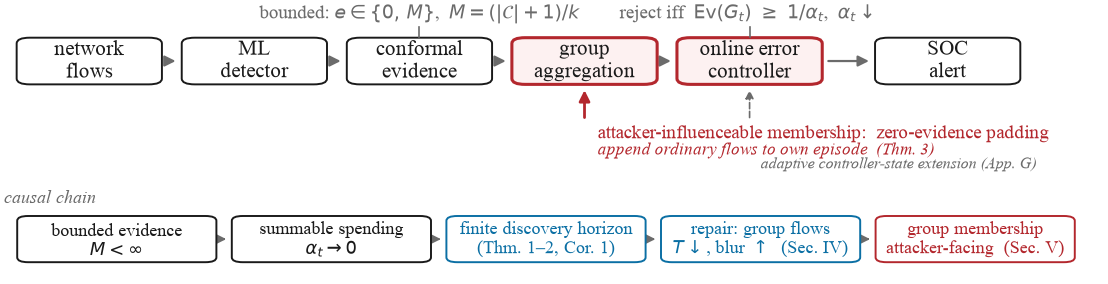

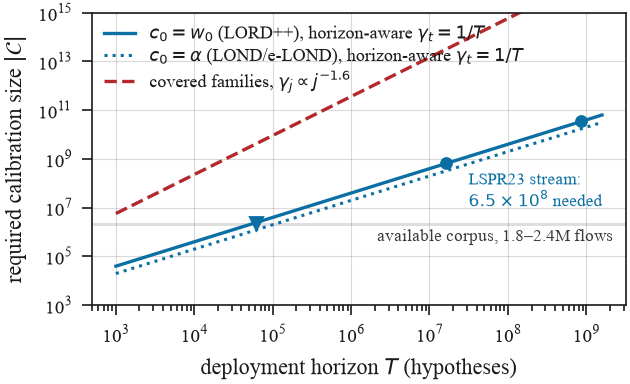

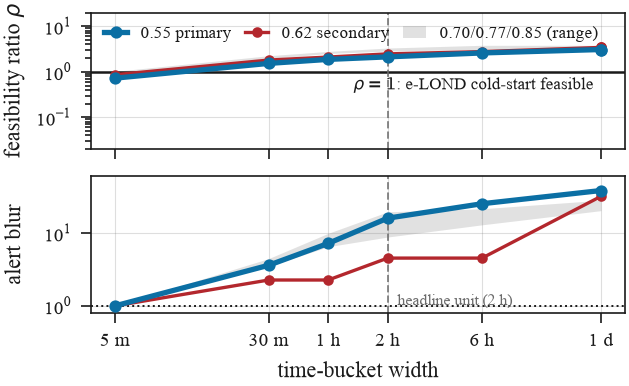

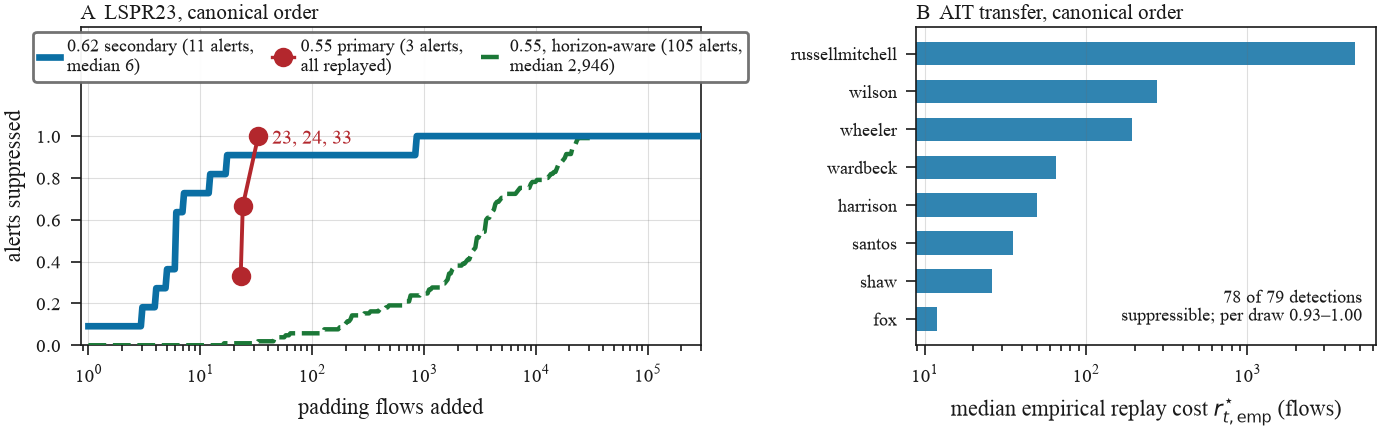

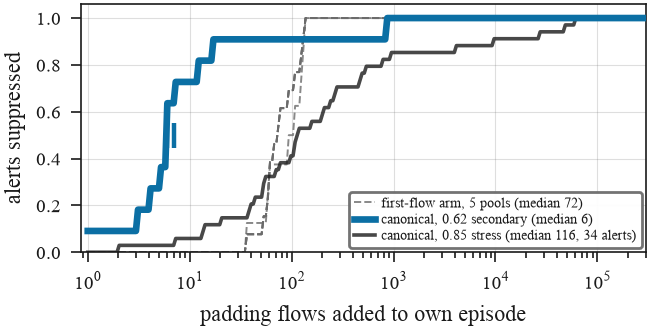

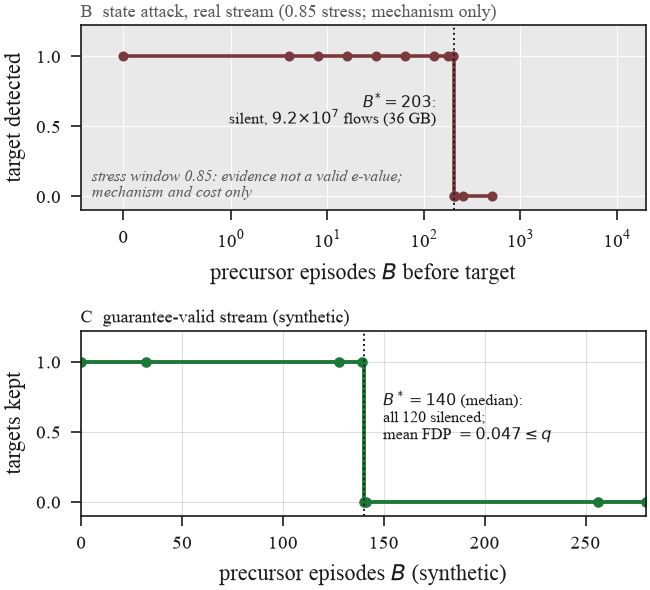

In [53]:
import figures

# OUTDIR stays None, so nothing is written to disk: each call returns a Figure and the notebook
# renders it inline. The paper build sets figures.OUTDIR and gets the same PDFs from this code.
for name, caption in figures.SUBMISSION:
    print(caption)
    display(getattr(figures, name)())

print(f"\n{len(figures.SUBMISSION)} figures rendered from lib/out (figures.RES)")


**The generated tables.** `lib/tables.py` writes every table the paper `\input`s from `lib/out`; it is
the code `paper/make_appendix_tables.py` wraps. Here it writes into a temporary directory, so the shipped
package is left untouched.

In [54]:
import tables, tempfile
tables.OUTDIR = Path(tempfile.mkdtemp()) / "tables"
with contextlib.redirect_stdout(io.StringIO()):
    written = tables.build_all()
print(f"{len(written)} table files rebuilt from lib/out into {tables.OUTDIR}")
print("  " + ", ".join(sorted(p.stem for p in written)))

48 table files rebuilt from lib/out into /var/folders/rn/31yn211d2r90mg7rxfz_tspm0000gn/T/tmp_bmub3x5/tables
  a1strata, a1strataprose, addisstate, addissynth, aitorder, aitsupp, aitsuppprose, audit, bates, blindkey, blindkeyprose, caps, cor2diag, cor2diagprose, detection, feedback, frontier85, groupcal, grouping, insertion, joint, joint76, joint76prose, joint76rel, joint76relprose, jointprose, nonoracle, ordering, padpools, pools, prevalence, prevalenceprose, procmatrix, qsweep, r7ait, r7host, r7hostprose, restart, semblur, semblurprose, smoothing, tail, transfer, uai26, units, w3dilution, w3dilutionprose, w7coverage


---
## 8. Summary

The three contributions, with the scope each is stated under:

**C1.** Under finite-resolution conformal evidence and an uninterrupted controller from the
covered structural families, bounded evidence creates a finite discovery horizon and an
absorbing rejection-free state. Removing either premise is possible and is tested above;
each removal has a measured cost.

**C2.** Coarsening the alerting unit restores feasibility exactly by reducing the hypothesis
count, and is paid for in episode-level resolution.

**C3.** The aggregation and controller state that make the trust layer usable are themselves
attacker-manipulable, within a hypothesis and across hypotheses, and for a majority of
detections the two attacks are one operation.